In [1]:
# Basics and image preprocessing
import os
import glob
import torch
import torchvision.transforms as transforms
import numpy as np
import cv2
import cv2 as cv
from PIL import Image , ImageOps
import math as mt
from matplotlib import pyplot as plt
import pandas as pd
import time
import pickle 
import random as rn
from sklearn.metrics import f1_score
from PIL import ImageFilter
import pickle 
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

#Pytorch and machine learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from sklearn.model_selection import train_test_split
from torch.nn import Flatten
from torch.autograd import Variable
import optuna
import torch.nn.functional as F
from typing import List
from ignite.metrics.confusion_matrix import ConfusionMatrix as CM

from torcheval.metrics.functional import binary_f1_score as F1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%cd "C:\Users\jiaru\Documents\code_temp_files\NTU"

C:\Users\jiaru\.conda\envs\AM_MM_use\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\jiaru\Documents\code_temp_files\NTU


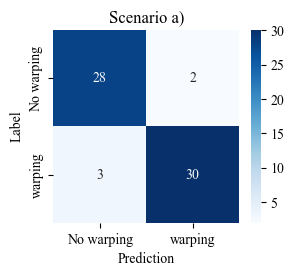

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.family"] = "Times New Roman"
# Confusion matrix values
confusion_matrix_values = np.array([[28, 2],  # [True Negative, False Positive]
                                    [3, 30]])  # [False Negative, True Positive]

# Class labels
class_names = ["No warping", "warping"]

# Plot the confusion matrix
plt.figure(figsize=(3, 2.5))
sns.heatmap(confusion_matrix_values, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Scenario a)")
plt.xlabel("Prediction")
plt.ylabel("Label")
plt.savefig('SA.svg')
plt.show()

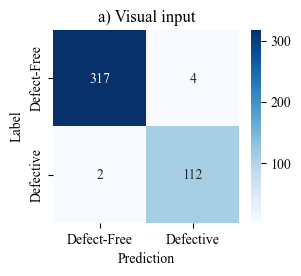

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.family"] = "Times New Roman"
# Confusion matrix values
confusion_matrix_values = np.array([[317, 4],  # [True Negative, False Positive]
                                    [2, 112]])  # [False Negative, True Positive]

# Class labels
class_names = ["Defect-Free", "Defective"]

# Plot the confusion matrix
plt.figure(figsize=(3, 2.5))
sns.heatmap(confusion_matrix_values, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("a) Visual input")
plt.xlabel("Prediction")
plt.ylabel("Label")
plt.savefig('confusion_matrix_image.svg')
plt.show()

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def utility(seed=42):
    seed = seed
    os.environ['PYTHONHASHSEED'] = '0'
    np.random.seed(seed)
    rn.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

# Data reading and preprocessing

In [5]:
img = Image.open('LDED-Audio-Visual-Demo-Dataset\\sample-1\\images\\sample_1_3.jpg')
img_array = np.array(img)

In [6]:
def compile_data(dataset):
    data_input = np.zeros((len(dataset),dataset[0][1].shape[0],dataset[0][1].shape[1]))#
    data_label = np.zeros((len(dataset),1))
    for i in range(len(dataset)):#range(40)
        data_input[i] = dataset[i][1]
        data_label[i] = dataset[i][-1]
    #     plt.pcolormesh(abnormal_record[i][3], abnormal_record[i][4], abnormal_record[i][5])
    #     plt.imshow(abnormal_record[i][5])
    #     plt.savefig(str(i)+'.png')
    return data_input, data_label

filereader = open('sample_record_IM_25.obj', 'rb') 
sample_record = pickle.load(filereader)

df = pd.read_csv('LDED-Audio-Visual-Demo-Dataset\\sample-1\\annotations_1.csv')

normal_record = []
abnormal_record = []
LF_record = []
for record in sample_record:
    ind = df.index[df['image_file_name'] == record[0]]
    if df['class_name'][ind[0]] == 'Defect-free':
        normal_record.append(record+[[0]])
    elif df['class_name'][ind[0]] == 'Defective':
        abnormal_record.append(record+[[1]])
    elif df['class_name'][ind[0]] == 'Laser-off':
        LF_record.append(record+[1])

normal_input_IM, normal_label_IM = compile_data(normal_record)
abnormal_input_IM, abnormal_label_IM = compile_data(abnormal_record)

In [7]:
filereader = open('sample_record_AE_80.obj', 'rb') 
sample_record = pickle.load(filereader)

df = pd.read_csv('LDED-Audio-Dataset\\sample-1\\annotations_1.csv')

normal_record = []
abnormal_record = []
LF_record = []
for record in sample_record:
    ind = df.index[df['audio_file_name'] == record[0]]
    if df['class_name'][ind[0]] == 'Defect-free':
        normal_record.append(record+[[0]])
    elif df['class_name'][ind[0]] == 'Defective':
        abnormal_record.append(record+[[1]])
    elif df['class_name'][ind[0]] == 'Laser-off':
        LF_record.append(record+[1])

normal_input_AE, normal_label_AE = compile_data(normal_record)
abnormal_input_AE, abnormal_label_AE = compile_data(abnormal_record)

In [8]:
np.std(abnormal_input_AE[100])

460.6288983607046

In [9]:
class CustomDataset(Dataset):
    def __init__(self, X, Y, transform=None):
        self.X = X
        self.Y = Y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        sample = {'image': self.X[idx], 'label': self.Y[idx]}
        sample['image'] = torch.tensor(self.X[idx], dtype=torch.float32)#.unsqueeze(0)
        sample['label'] = torch.tensor(self.Y[idx], dtype=torch.float32)
        
        return sample

In [10]:
def dataprep(normal_input,normal_label,abnormal_input, abnormal_label):
    data_input = np.concatenate((normal_input,abnormal_input),0)
    data_label = np.concatenate((normal_label,abnormal_label),0)

    n_total = len(data_input)

    np.random.seed(32)
    np.random.shuffle(data_input)
    np.random.seed(32)
    np.random.shuffle(data_label)
    train_data_input = data_input[:int(n_total*0.8)]
    val_data_input = data_input[int(n_total*0.8):int(n_total*0.9)]
    test_data_input = data_input[int(n_total*0.9):]

    train_data_label = data_label[:int(n_total*0.8)]
    val_data_label = data_label[int(n_total*0.8):int(n_total*0.9)]
    test_data_label = data_label[int(n_total*0.9):]
    
    sc_min = np.min(train_data_input)
    sc_max = np.max(train_data_input)
    print(sc_min,sc_max)
    train_data_input_sc = (train_data_input-0)/sc_max-0
    train_data_input_sc = train_data_input_sc.reshape(train_data_input_sc.shape[0],1,train_data_input_sc.shape[1],train_data_input_sc.shape[2])
    val_data_input_sc = (val_data_input-0)/sc_max-0
    val_data_input_sc = val_data_input_sc.reshape(val_data_input_sc.shape[0],1,val_data_input_sc.shape[1],val_data_input_sc.shape[2])
    test_data_input_sc = (test_data_input-0)/sc_max-0
    test_data_input_sc = test_data_input_sc.reshape(test_data_input_sc.shape[0],1,test_data_input_sc.shape[1],test_data_input_sc.shape[2])
    
    BATCHSIZE = 128
    train_dataset = CustomDataset(train_data_input_sc, train_data_label)
    val_dataset = CustomDataset(val_data_input_sc, val_data_label)
    test_dataset = CustomDataset(test_data_input_sc, test_data_label)
    train_loader = DataLoader(train_dataset, batch_size=BATCHSIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCHSIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
    return train_loader,val_loader,test_loader,train_data_input_sc,val_data_input_sc,test_data_input_sc,test_data_input

train_loader_IM,val_loader_IM,test_loader_IM,train_data_input_sc_IM,val_data_input_sc_IM,test_data_input_sc_IM,test_data_input_IM = dataprep(normal_input_IM,normal_label_IM,abnormal_input_IM,abnormal_label_IM)
train_loader_AE,val_loader_AE,test_loader_AE,train_data_input_sc_AE,val_data_input_sc_AE,test_data_input_sc_AE,test_data_input_AE = dataprep(normal_input_AE,normal_label_AE,abnormal_input_AE,abnormal_label_AE)

0.0 255.0
4.931210237057516e-11 41888.4260690269


In [11]:
# Initialize the model, loss function, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 5
n_class = 2

# Early stopping parameters
patience = 5
best_loss = float('inf')
counter = 0

# CCSA

In [12]:
# Define your neural network architecture
class SharedConvNet(nn.Module):
    utility()
    def __init__(self, num_conv_layers, filters1, filters2,kernal_size):
        super(SharedConvNet, self).__init__()
        utility()
        self.conv_layers = nn.ModuleList()
        self.pool_layers = nn.ModuleList()

        self.conv_layers.append(nn.Conv2d(1, filters1, kernel_size=kernal_size, padding='same'))
        self.pool_layers.append(nn.MaxPool2d(2, 2))
        for _ in range(num_conv_layers):
            self.conv_layers.append(nn.Conv2d(filters1, filters1, kernel_size=kernal_size, padding='same'))
            self.pool_layers.append(nn.MaxPool2d(1, 1))

        self.conv_layers.append(nn.Conv2d(filters1, filters2, kernel_size=kernal_size, padding='same'))
        self.pool_layers.append(nn.MaxPool2d(2, 2))
        self.conv_layers.append(nn.Conv2d(filters2, filters2*2, kernel_size=kernal_size, padding='same'))
        self.pool_layers.append(nn.MaxPool2d(2, 2))
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        
#         self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding='same')
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding='same')
#         self.bn1 = nn.BatchNorm2d(64)
#         self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding='same')
#         self.bn2 = nn.BatchNorm2d(64)
#         self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding='same')
#         self.bn3 = nn.BatchNorm2d(128)
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
#         self.relu = nn.ReLU()

    def forward(self, x):
        for conv, pool in zip(self.conv_layers, self.pool_layers):
            x = pool(F.relu(conv(x)))
        x = self.flatten(x)#x = x.view(-1, filters2 * 10 * 10)
        return x

class ClassifierNet(nn.Module):
    utility()
    def __init__(self, dense_units1,output_dims: List[int],drops, filters2):
        super(ClassifierNet, self).__init__()
        self.dense_layers = nn.ModuleList()
        self.drop_layers = nn.ModuleList()
        
        flat_dim = filters2*2 * 10 * 10#filters2 * 2 * 15 * 15
        self.dense_layers.append(nn.Linear(flat_dim, dense_units1))
        self.drop_layers.append(nn.Dropout(drops))
        input_dim = dense_units1
        for j in range(len(output_dims)):
            self.dense_layers.append(nn.Linear(input_dim, output_dims[j]))
            self.drop_layers.append(nn.Dropout(drops))
            input_dim = output_dims[j]
        self.fc3 = nn.Linear(input_dim, 1)
        
#         self.fc1 = nn.Linear(128 * 10 * 10, 128)  # Adjust input size based on your architecture
#         self.fc2 = nn.Linear(128, 96)  # Adjust input size based on your architecture
#         self.fc3 = nn.Linear(96, 1)

    def forward(self, x):
        for dense,drop in zip(self.dense_layers,self.drop_layers):
            x = F.relu(drop(dense(x)))
        x = self.fc3(x)
        return F.sigmoid(x)

In [13]:
def pairwise_y(X, Y):
    batch_size_x = X.shape[0]
    batch_size_y = Y.shape[0]
    dim = int(torch.prod(torch.tensor(X.shape[1:])).item())
    
    X = X.view(batch_size_x, dim)
    Y = Y.view(batch_size_y, dim)
    
    X = X.unsqueeze(-1).expand(batch_size_x, dim, batch_size_y)
    Y = Y.unsqueeze(-1).expand(batch_size_y, dim, batch_size_x).transpose(0, 2)
    
    return torch.sum(torch.abs(X - Y), 1) / 2.0

In [14]:
def pairwise_X(X, Y):
    X2 = torch.tile(torch.sum(X**2, dim=1, keepdim=True), [1, Y.shape[0]])
    Y2 = torch.tile(torch.sum(Y**2, dim=1, keepdim=True), [1, X.shape[0]])
#     print(Y.shape)
    XY = torch.matmul(X, Y.t())
    return X2 + Y2.t() - 2 * XY

In [15]:
def train(encoder_net,task_net,device, source_train_loader,target_train_loader, encoder_optim,classifier_optim):
    utility()
    encoder_net.train()
    task_net.train()
    # Other hyperparameters
    EPS = 1e-8 # A very small number
    margin = 1 # margin between normal and abnormal classes
    gamma = 0.5 # Weight between the classification and contrastive losses
    for batch in zip(source_train_loader, target_train_loader):
        source_batch, target_batch = batch

        source_images, source_labels = source_batch['image'].cuda(), source_batch['label'].cuda()
        target_images, target_labels = target_batch['image'].cuda(), target_batch['label'].cuda()

        encoder_net.zero_grad()
        task_net.zero_grad()
        
        weight_negative = 3  # Weight for class 0 (negative class)
        weight_positive = 1  # Weight for class 1 (positive class)
        weights = torch.full_like(target_labels, weight_negative)  # Initialize weights with weight for class 0
        weights[target_labels == 1] = weight_positive  # Assign weight for class 1 where target is 1
        criterion = torch.nn.BCELoss(weights)
        
        if source_labels.dim() <= 1 or source_labels.size(1) == 1:
            source_labels_is_1d = True
        else:
            source_labels_is_1d = False
            
        # # Updating Convolutional encoder (CE)
        enc_source = encoder_net(source_images)
        enc_target = encoder_net(target_images)

        source_output = task_net(enc_source)
        target_output = task_net(enc_target)
        
        task_loss = criterion(source_output.view(len(source_output),1), source_labels.view(len(source_labels),1))#L_C classification loss to update task network
        task_loss += criterion(target_output.view(len(target_output),1), target_labels.view(len(target_labels),1))#L_C classification loss to update task network
        task_loss = task_loss/2
        dist_y = pairwise_y(source_labels, target_labels)            
        dist_X = pairwise_X(enc_source, enc_target)
        
        if source_labels_is_1d:
            dist_y *= 2
            
        contrastive_loss = torch.sum(dist_y * torch.maximum(torch.tensor(0.0), margin - dist_X), 1) / (torch.sum(dist_y, 1) + EPS)
        contrastive_loss += torch.sum((1 - dist_y) * dist_X, 1) / (torch.sum(1 - dist_y, 1) + EPS)
        contrastive_loss = torch.mean(contrastive_loss)
        contrastive_loss *= 0.5
        
#         target_loss = criterion(target_output, target_labels)
        enc_loss = gamma*task_loss + (1-gamma)*contrastive_loss#task_loss + gamma*contrastive_loss #L_CCSA = L_C + L_SA + L_S
        enc_loss.backward()#retain_graph=True
        encoder_optim.step()   
#         CE_loss_ += enc_loss.item()
#         SA_loss_ += contrastive_loss.item()

        #  Updating task classifer (TC)
        enc_source = encoder_net(source_images)
        enc_target = encoder_net(target_images)

        source_output = task_net(enc_source)
        target_output = task_net(enc_target)
        
        task_loss = criterion(source_output.view(len(source_output),1), source_labels.view(len(source_labels),1))#L_C classification loss to update task network
        task_loss += criterion(target_output.view(len(target_output),1), target_labels.view(len(target_labels),1))#L_C classification loss to update task network
        task_loss = task_loss/2
        task_loss.backward()#retain_graph=True
        classifier_optim.step()
    return enc_loss, contrastive_loss, task_loss

def evaluate(encoder_net,task_net, device, target_any_loader):
    encoder_net.eval()
    task_net.eval()
    correct = 0
    total = 0
    f1s = 0
    iters = 0
    with torch.no_grad():
         for batch in target_any_loader:
            data, target = batch['image'].cuda(), batch['label'].to(device)
            n_target = len(target)
            code = encoder_net.forward(data)
            output = task_net.forward(code)
            output = output.view(target.size(0))
            target = target.view(target.size(0))
            iters += 1
#             f1s += F1(target,output)
            accuracy = 1-torch.sum(torch.abs(target-torch.round(output)))/n_target
            f1s += accuracy
    return f1s / iters

In [16]:
# Define a callback function to record the results
def callback(study, trial):
    trial_data = {
        "trial_number": trial.number,
#         "Start_time": trial.datetime_start,
#         "Training_time": trial.traintime
        **trial.params,  # Unpack params
        "Validation_accuracy": trial.value,
#         "Epochs": EPOCHS
    }
    results.append(trial_data)

In [248]:
# Define the objective function for Optuna
def objective(trial):
    
    # Encoder hyperparameters
    num_conv_layers = trial.suggest_int('num_conv_layers', 0, 2)
    filters1 = trial.suggest_int('filters1', 16, 32)
    filters2 = trial.suggest_int('filters2', 32, 48)
    kernal_size = trial.suggest_int('kernal_size', 2, 4)
    
    # Classifier hyperparameters
    dense_units1_TC = trial.suggest_int('dense_units1_TC', 128, 360)
#     dense_units2 = trial.suggest_int('dense_units2', 64, 256)
    
    num_dense_layers_TC = trial.suggest_int('num_dense_layers_TC', 0, 2)
    output_dims_TC = [
        trial.suggest_int("output_dims_TC{}".format(i), 32, 256, log=True) for i in range(num_dense_layers_TC)
    ]
    drops_TC = trial.suggest_float("drops_TC", 0.01, 0.1, log=True)
#     weighting = trial.suggest_int("weighting", 1, 3, log=True)

    
    lr = trial.suggest_float("lr", 1e-6, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-7, 1e-3)
#     alpha = trial.suggest_float('alpha', 1, 5)
    
    
    # model setups
    criterion_task = nn.BCELoss()
    criterion_disc = nn.BCEWithLogitsLoss()

    EPS = 1e-8
    epochs = 1200
    utility()

    encoder_net = SharedConvNet(num_conv_layers, filters1, filters2,kernal_size).cuda()
    task_net = ClassifierNet(dense_units1_TC,output_dims_TC,drops_TC, filters2).cuda()

    encoder_optim = torch.optim.Adam(encoder_net.parameters(), lr=lr,weight_decay=weight_decay)
    classifier_optim = torch.optim.Adam(task_net.parameters(), lr=lr,weight_decay=weight_decay)
    
    for epoch in range(epochs):  # You can adjust the number of epochs
        ls = train(encoder_net,task_net, device, train_loader_IM, train_loader_AE, encoder_optim,classifier_optim)

    f1_score = evaluate(encoder_net,task_net, device, val_loader_IM)
    return f1_score

In [16]:
utility()
results = []
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=300, callbacks=[callback])

print('Number of finished trials: ', len(study.trials))
print('Best trial:')
trial = study.best_trial
df = pd.DataFrame(results)
# Sort results based on trial value
df_sorted = df.sort_values(by='Validation_accuracy', ascending=True)
# Select top 50 hyperparameter sets
top_50 = df_sorted.tail(300)

top_50.to_excel("optuna_results_IMAE_DED_CCSA_optuna.xlsx", index=False)

print('Value: ', trial.value)
print('Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')

[I 2024-09-18 21:18:03,560] A new study created in memory with name: no-name-560fc2d0-3fb7-4b6c-9fa6-d6a6f7a7efa6
[W 2024-09-18 21:18:13,706] Trial 0 failed with parameters: {'num_conv_layers': 0, 'filters1': 18, 'filters2': 44, 'kernal_size': 3, 'dense_units1_TC': 179, 'num_dense_layers_TC': 2, 'output_dims_TC0': 51, 'output_dims_TC1': 152, 'drops_TC': 0.01423430739351086, 'lr': 0.00010561693518487611, 'weight_decay': 0.00041502650511245087} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\jiaru\.conda\envs\AM_MM\lib\site-packages\optuna\study\_optimize.py", line 200, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\jiaru\AppData\Local\Temp\ipykernel_48508\240632672.py", line 42, in objective
    ls = train(encoder_net,task_net, device, train_loader_IM, train_loader_AE, encoder_optim,classifier_optim)
  File "C:\Users\jiaru\AppData\Local\Temp\ipykernel_48508\3379545274.py", line 12, in train
    source_images, sou

KeyboardInterrupt: 

In [61]:
top_candidates = pd.read_excel('optuna_results_IMAE_DED_CCSA_optuna_part2.xlsx', index_col=0)
# Sort results based on trial value
df_sorted = top_candidates.sort_values(by='Validation_accuracy', ascending=True)
# Select top 50 hyperparameter sets
top_candidates = df_sorted.tail(50)

In [249]:
def evaluate(encoder_net,task_net, device, target_any_loader):
    encoder_net.eval()
    task_net.eval()
    correct = 0
    total = 0
    f1s = 0
    iters = 0
    outputs = []
    targets = []
    with torch.no_grad():
         for batch in target_any_loader:
            data, target = batch['image'].cuda(), batch['label'].to(device)
            n_target = len(target)
            code = encoder_net.forward(data)
            output = task_net.forward(code)
            output = output.view(target.size(0))
            target = target.view(target.size(0))
            iters += 1
#             f1s += F1(target,output)
            accuracy = 1-torch.sum(torch.abs(target-torch.round(output)))/n_target
            f1s += accuracy
#             print(target-torch.round(output))
            discrepancies = target-torch.round(output)
    return f1s / iters, discrepancies

In [17]:
# model setups
criterion_task = nn.BCELoss()
criterion_disc = nn.BCEWithLogitsLoss()

EPS = 1e-8
epochs = 1200
utility()

encoder_net = SharedConvNet(2, 30, 32,3).cuda()
task_net = ClassifierNet(220,[93],0.0752054726602688, 32).cuda()

encoder_optim = torch.optim.Adam(encoder_net.parameters(), lr=0.000484674265378098,weight_decay=0.000793891463437805)
classifier_optim = torch.optim.Adam(task_net.parameters(), lr=0.000484674265378098,weight_decay=0.000793891463437805)

enc_rec = []
contrastive_rec = []
task_rec = []
for epoch in range(1200):  # You can adjust the number of epochsepochs
    print(epoch)
    enc_ls, contrastive_ls, task_ls = train(encoder_net,task_net, device, train_loader_IM, train_loader_AE, encoder_optim,classifier_optim)
    enc_loss = enc_ls.cpu().detach().numpy()
    contrastive_loss = contrastive_ls.cpu().detach().numpy()
    task_loss = task_ls.cpu().detach().numpy()
    enc_rec.append(enc_loss)
    contrastive_rec.append(contrastive_loss)
    task_rec.append(task_loss)
    


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [51]:
total_params = sum(p.numel() for p in encoder_net.parameters() if p.requires_grad)

print(f'Total number of weights (trainable parameters): {total_params}')

Total number of weights (trainable parameters): 16286


In [52]:
total_params = sum(d.numel() for d in task_net.parameters() if d.requires_grad)

print(f'Total number of weights (trainable parameters): {total_params}')

Total number of weights (trainable parameters): 1275599


In [18]:
evaluate(encoder_net,task_net,device, train_loader_AE)

tensor(0.9930, device='cuda:0')

In [19]:
evaluate(encoder_net,task_net,device, val_loader_AE)

tensor(0.9234, device='cuda:0')

In [20]:
evaluate(encoder_net,task_net,device, test_loader_AE)

tensor(0.9333, device='cuda:0')

In [150]:
# score, discrepancies = evaluate(encoder_net,task_net,device, test_loader_AE)

In [279]:
evaluate(encoder_net,task_net,device, train_loader_IM)

(tensor(0.9994, device='cuda:0'),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        device='cuda:0'))

In [280]:
evaluate(encoder_net,task_net,device, val_loader_IM)

(tensor(0.9805, device='cuda:0'),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.], device='cuda:0'))

In [281]:
evaluate(encoder_net,task_net,device, test_loader_IM)

(tensor(0.9632, device='cuda:0'),
 tensor([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.,
          0., -1.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,

In [29]:
score, discrepancies = evaluate(encoder_net,task_net,device, test_loader_IM)

In [30]:
score

tensor(0.9816, device='cuda:0')

In [31]:
indices_of_falsenegative = torch.nonzero(discrepancies == 1, as_tuple=True)[0]
indices_of_falsenegative

tensor([246, 370], device='cuda:0')

In [32]:
indices_of_falsepositive = torch.nonzero(discrepancies == -1, as_tuple=True)[0]
indices_of_falsepositive

tensor([ 25,  51, 261, 264, 302, 414], device='cuda:0')

In [50]:
test_data_input_IM[indices_of_falsenegative.cpu()][0]

array([[117., 117., 118., ..., 115., 115., 114.],
       [117., 116., 117., ..., 115., 115., 114.],
       [116., 115., 117., ..., 115., 114., 113.],
       ...,
       [100., 100., 103., ..., 100.,  98.,  96.],
       [101., 101., 103., ..., 100.,  98.,  97.],
       [ 90.,  90.,  92., ...,  88.,  87.,  86.]])

In [59]:
for i in range(len(indices_of_falsenegative)):
    img = Image.fromarray(test_data_input_IM[indices_of_falsenegative.cpu()][i].astype(np.uint8), 'L')
    img.save('investigation\\CMKT\\IM\\FN'+str(indices_of_falsenegative.cpu()[i])+'.png')
#     img.show()

In [61]:
for i in range(len(indices_of_falsepositive)):
    img = Image.fromarray(test_data_input_IM[indices_of_falsepositive.cpu()][i].astype(np.uint8), 'L')
    img.save('investigation\\CMKT\\IM\\FP'+str(indices_of_falsepositive.cpu()[i])+'.png')
#     img.show()

# Lime

In [138]:
import lime
from lime import lime_image
from skimage.color import gray2rgb
from torchvision import transforms
from torch.nn.functional import softmax
from skimage.color import rgb2gray

In [141]:
encoder_net.eval()
task_net.eval()
encoder_net_cpu = encoder_net.cuda()
task_net_cpu = task_net.cuda()

In [140]:
def preprocess_and_predict(input_image):
#     # Convert the numpy grayscale image to a PyTorch tensor
#     preprocess = transforms.Compose([
#         input_image_sc = (input_image-0)/sc_max-0,
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.5], std=[0.5])  # Adjust based on your model's needs
#     ])
    
#     image_tensor = preprocess(input_image).unsqueeze(0)  # Add batch dimension
    input_image = rgb2gray(input_image)
#     print(input_image.shape)
    input_image_sc = (input_image-0)/255
#     print(input_image_sc.shape)
    input_image_sc = torch.tensor(input_image_sc, dtype=torch.float32)
#     print(input_image_sc)
    input_image_sc = input_image_sc.view(10,1, 80,80)
    input_image_sc = input_image_sc.cuda()
    
    # Get the model's prediction (probabilities)
    with torch.no_grad():
        code = encoder_net.forward(input_image_sc)
        output = task_net.forward(code)
        output_0 = 1-output
#         print(torch.cat((output_0,output),1).numpy())
#         probabilities = softmax(output, dim=1).cpu().numpy()
        probabilities = torch.cat((output_0,output),1).cpu().numpy()
#         print(probabilities)
    
    return probabilities

In [34]:
from PIL import Image, ImageDraw
# Create an 80x80 blank grayscale image ('L' mode)
mask = Image.new('L', (80, 80), 0)  # 0 means black background

# Create a draw object to draw on the image
draw = ImageDraw.Draw(mask)

# Define center and radii for the hollow circle
center = (40, 45)  # The center of the 80x80 image
outer_radius = 35
inner_radius = 29

# Draw the outer circle (white = 255)
draw.ellipse((center[0] - outer_radius, center[1] - outer_radius, 
              center[0] + outer_radius, center[1] + outer_radius), fill=255)

# Draw the inner circle (black = 0) to make it hollow
draw.ellipse((center[0] - inner_radius, center[1] - inner_radius, 
              center[0] + inner_radius, center[1] + inner_radius), fill=0)

# Show or save the mask
# mask.show()  # To visualize the mask

In [35]:
mask_array = np.array(mask)/255

In [163]:
masks = np.zeros((len(test_data_input_IM),80,80))
intersections = []
for i in np.arange(len(test_data_input_IM)):
    print(i)
    # Use LIME to explain the model's predictions
    explainer = lime_image.LimeImageExplainer()

    input_image = test_data_input_IM[i]#test_data_input[indices_of_falsepositive.cpu()][0]
#     print(input_image.shape)

    # Explain the model's prediction
    explanation = explainer.explain_instance(input_image, preprocess_and_predict,labels =[0,1],num_features=10, hide_color=0, num_samples=10000)

    # Show the explanation
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False,negative_only=False, num_features=6,hide_rest=False)
    masks[i] = mask
#     array = np.where(mask == 0, 1, 0)
    
#     # Compute intersection (both masks have 1s)
#     intersection = np.logical_and(mask_array, array).sum()
#     intersections.append(intersection)

0


100%|██████████| 10000/10000 [00:03<00:00, 3220.32it/s]


1


100%|██████████| 10000/10000 [00:03<00:00, 2766.93it/s]


2


...

100%|██████████| 10000/10000 [00:07<00:00, 1261.85it/s]


433


100%|██████████| 10000/10000 [00:07<00:00, 1294.11it/s]


434


100%|██████████| 10000/10000 [00:07<00:00, 1392.33it/s]


In [164]:
import pickle
with open("investigation\\CMKT\\masks_150.pkl", "wb") as file:  # 'wb' stands for write in binary mode
    pickle.dump(masks, file)

In [129]:
import pickle
file = open("investigation\\CMKT_\\masks_1200.pkl",'rb')
masks = pickle.load(file)
file.close()

In [76]:
intersections = []
for i in np.arange(len(masks)):
    array = np.where(masks[i] == 1, 1, 0)
        
    # Compute intersection (both masks have 1s)
    intersection = np.logical_and(mask_array, array).sum()
    intersections.append(intersection)

In [77]:
np.mean(intersections)

432.6183908045977

In [78]:
import statistics 
statistics.pstdev(intersections) 

31.176914536239792

In [79]:
import csv
# Save to CSV
with open("investigation\\CMKT\\CMKT_intersect_1_600_1.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(intersections)  # Save the list as a single row

In [187]:
len(test_data_input_IM)

435

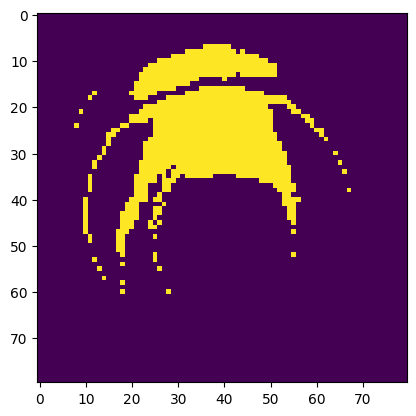

In [217]:
masks = np.where(masks == 1, 1, 0)
plt.imshow(masks[167])
plt.savefig('intersection_167_CMKT.svg')
plt.show()

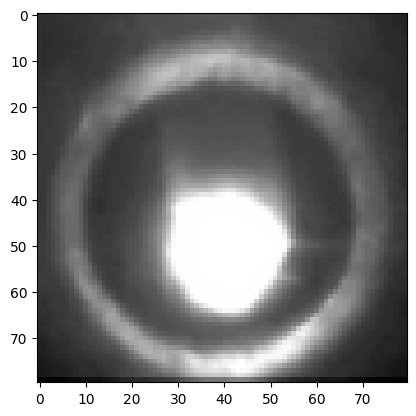

In [218]:
plt.imshow(test_data_input_IM[167].astype(int), cmap='gray')
plt.savefig('original_167.svg')

In [146]:
# Use LIME to explain the model's predictions
explainer = lime_image.LimeImageExplainer()

input_image = test_data_input_IM[413]#test_data_input[indices_of_falsepositive.cpu()][0]
# print(input_image.shape)

# Explain the model's prediction
explanation = explainer.explain_instance(input_image, preprocess_and_predict,labels =[0,1],num_features=10, hide_color=0, num_samples=1000)

# Show the explanation
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True,negative_only=False, num_features=1,hide_rest=True)

# # Optionally, visualize the result using matplotlib
# import matplotlib.pyplot as plt
# plt.imshow(temp, cmap='gray')
# plt.show()

100%|██████████| 1000/1000 [00:00<00:00, 3039.78it/s]


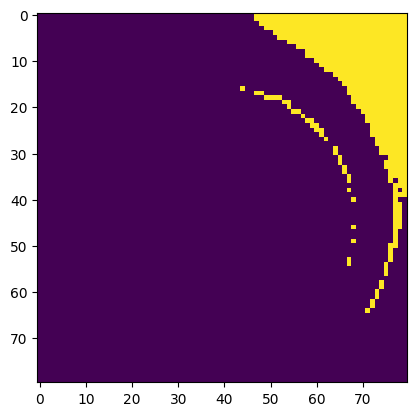

In [147]:
import matplotlib.pyplot as plt
plt.imshow(mask)
plt.show()

Text(0.5, 0, 'Number of epochs')

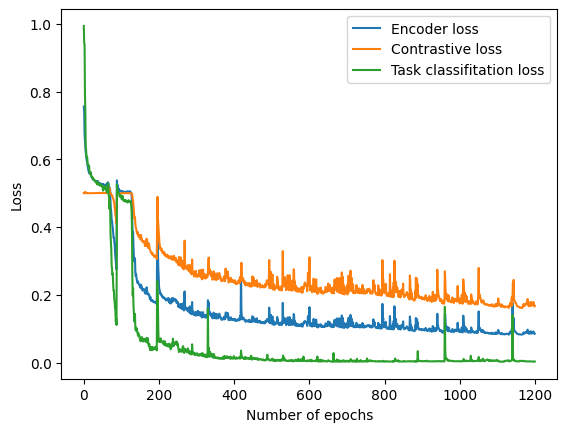

In [33]:
plt.plot(enc_rec)
plt.plot(contrastive_rec)
plt.plot(task_rec)
plt.legend(['Encoder loss','Contrastive loss','Task classifitation loss'])
plt.ylabel('Loss')
plt.xlabel('Number of epochs')
# plt.savefig('CCSA_loss.svg')

In [27]:
# with open('CCSA_encoder.pkl', 'wb') as file:
#     pickle.dump(encoder_net, file)
# with open('CCSA_classifier.pkl', 'wb') as file:
#     pickle.dump(task_net, file)

In [65]:
top_candidates = pd.read_excel('optuna_results_IMAE_DED_CCSA_optuna_part2.xlsx', index_col=0)
# Sort results based on trial value
df_sorted = top_candidates.sort_values(by='Validation_accuracy', ascending=True)
# Select top 50 hyperparameter sets
top_candidates = df_sorted.tail(50)

In [67]:
# def read_candidates():
import math
hyperparams = []
for i in range(len(top_candidates)):
    candidate = top_candidates.iloc[i]
    if math.isnan(candidate['output_dims_TC0']):
        hyperparams.append([int(candidate['num_conv_layers']),int(candidate['num_dense_layers_TC']),int(candidate['dense_units1_TC']),[],float(candidate['drops_TC']),int(candidate['filters1']),int(candidate['filters2']),int(candidate['kernal_size']),float(candidate['lr']),float(candidate['weight_decay'])])
    elif math.isnan(candidate['output_dims_TC1']):
        hyperparams.append([int(candidate['num_conv_layers']),int(candidate['num_dense_layers_TC']),int(candidate['dense_units1_TC']),[int(candidate['output_dims_TC0'])],float(candidate['drops_TC']),int(candidate['filters1']),int(candidate['filters2']),int(candidate['kernal_size']),float(candidate['lr']),float(candidate['weight_decay'])])
    elif math.isnan(candidate['output_dims_TC1']) is False:
        hyperparams.append([int(candidate['num_conv_layers']),int(candidate['num_dense_layers_TC']),int(candidate['dense_units1_TC']),[int(candidate['output_dims_TC0']),int(candidate['output_dims_TC1'])],float(candidate['drops_TC']),int(candidate['filters1']),int(candidate['filters2']),int(candidate['kernal_size']),float(candidate['lr']),float(candidate['weight_decay'])])


In [70]:
# Define the evaluation loop
from sklearn.metrics import roc_auc_score
from sklearn.metrics import balanced_accuracy_score
def evaluate(encoder_net,task_net, device, target_any_loader):
    encoder_net.eval()
    task_net.eval()
    correct = 0
    total = 0
    accuracy_total = 0
    baccuracy_total = 0
    iters = 0
    roc_auc_total = 0
    with torch.no_grad():
        for batch in target_any_loader:
            data, target = batch['image'].cuda(), batch['label'].to(device)
            n_target = len(target)
            code = encoder_net.forward(data)
            output = task_net.forward(code)
            output = output.view(target.size(0))
            target = target.view(target.size(0))
            iters += 1
#             f1s += F1(target,output)
            accuracy = 1-torch.sum(torch.abs(target-torch.round(output)))/n_target
            roc_auc = roc_auc_score(target.cpu().detach().numpy(), output.cpu().detach().numpy())
            baccuracy = balanced_accuracy_score(target.cpu().detach().numpy(), torch.round(output).cpu().detach().numpy())
            accuracy_total += accuracy
            roc_auc_total += roc_auc
            baccuracy_total += baccuracy
        accuracy_ = accuracy_total / iters
        roc_auc_ = roc_auc_total / iters
        baccuracy_ = baccuracy_total / iters
    return float(accuracy_.cpu().detach().numpy()), float(roc_auc_),float(baccuracy_)

In [ ]:
performance_rec = []
for i in range(len(hyperparams)):#
    print(i)
    utility()
    encoder_net = SharedConvNet(hyperparams[i][0], hyperparams[i][5], hyperparams[i][6],hyperparams[i][7]).cuda()
    task_net = ClassifierNet(hyperparams[i][2],hyperparams[i][3],hyperparams[i][4], hyperparams[i][6]).cuda()

    encoder_optim = torch.optim.Adam(encoder_net.parameters(), lr=hyperparams[i][8],weight_decay=hyperparams[i][9])
    classifier_optim = torch.optim.Adam(task_net.parameters(), lr=hyperparams[i][8],weight_decay=hyperparams[i][9])

    t1 = time.time()
    for epoch in range(epochs):  # You can adjust the number of epochs
#         print(epoch)
        enc_ls, contrastive_ls, task_ls = train(encoder_net,task_net, device, train_loader_IM, train_loader_AE, encoder_optim,classifier_optim)
    train_time = (time.time()-t1)
    
    t1 = time.time()
    train_acc, train_auc, train_bacc = evaluate(encoder_net,task_net,device, train_loader_IM)
    predict_time = (time.time()-t1)
    val_acc, val_auc, val_bacc = evaluate(encoder_net,task_net,device, val_loader_IM)
    test_acc, test_auc, test_bacc = evaluate(encoder_net,task_net,device, test_loader_IM)
    performance_rec.append([train_acc,val_acc,test_acc, train_auc, val_auc, test_auc, train_bacc, val_bacc, test_bacc,train_time,predict_time])
    print(train_acc,val_acc,test_acc, train_auc, val_auc, test_auc, train_bacc, val_bacc, test_bacc,train_time,predict_time)

0
0.9972098469734192 0.986328125 0.9736136794090271 0.9999448052062848 0.9988992714500239 0.9973087141555186 0.9941196472446473 0.9830472917443511 0.9581696733717411 853.4373223781586 0.16570663452148438
1
0.9980469346046448 0.986328125 0.9775199294090271 0.9999777061798746 0.9984520569155064 0.99768559487192 0.9964280300762859 0.9802905438839167 0.9599934291898577 709.1515798568726 0.1593339443206787
2
0.9974888563156128 0.986328125 0.9697074294090271 0.9999655584636452 0.998776958031903 0.9969062011766429 0.9956486977247885 0.9754334190431666 0.9487847052696677 820.3782949447632 0.1684577465057373
3
0.9960938096046448 0.986328125 0.9794730544090271 0.999882661332883 0.9992728200033502 0.9970946796780913 0.9919991115303615 0.9776169814715744 0.9620767625231911 709.016339302063 0.14960718154907227
4
0.994698703289032 0.990234375 0.9755668044090271 0.9998949274537556 0.9983880969790787 0.9969647892051557 0.9889060942940253 0.9834979351721989 0.9559314275949614 816.2255094051361 0.141463

In [ ]:
df = pd.DataFrame(performance_rec)
writer = pd.ExcelWriter('performance_IMAE_DED_CCSA_optuna.xlsx', engine='xlsxwriter')
df.to_excel(writer, sheet_name='performance', index=False)
writer.close()

In [29]:
with open('CCSA_encoder.pkl', 'rb') as file:
    encoder_network = pickle.load(file)
with open('CCSA_classifier.pkl', 'rb') as file:
    task_network = pickle.load(file)

# Visualize the encoded space

In [26]:
def visualize(data_loader,network,original_dim):
    network.eval()
    normal = torch.ones((1,original_dim)).cuda()
    abnormal = torch.ones((1,original_dim)).cuda()
    with torch.no_grad():
        for batch in data_loader:
            data, target = batch['image'].cuda(), batch['label'].to(device)
            n_target = len(target)
            code = network.forward(data)
            for i in range(n_target):
                if target[i] == 0:
                    normal = torch.cat((normal,code[i].view(1,original_dim)),0)
                else:
                    abnormal = torch.cat((abnormal,code[i].view(1,original_dim)),0)

    return normal[1:], abnormal[1:]

In [30]:
normal_AE, abnormal_AE = visualize(train_loader_AE,encoder_net,6400)
normal_IM, abnormal_IM = visualize(train_loader_IM,encoder_net,6400)

In [31]:
import numpy as np

def gaussian_kernel(x, y, sigma=1.0):
    """
    Compute the Gaussian kernel between two samples x and y.
    
    Parameters:
    x : numpy array
        A sample.
    y : numpy array
        Another sample.
    sigma : float
        Bandwidth parameter for the Gaussian kernel.
    
    Returns:
    float
        The result of the Gaussian kernel applied to samples x and y.
    """
    return np.exp(-np.linalg.norm(x - y)**2 / (2 * (sigma**2)))

def mmd_squared(x, y, sigma=1.0):
    """
    Compute the squared Maximum Mean Discrepancy (MMD) between two datasets x and y.

    Parameters:
    x : numpy array
        First dataset.
    y : numpy array
        Second dataset.
    sigma : float
        Bandwidth parameter for the Gaussian kernel.

    Returns:
    float
        The squared MMD between datasets x and y.
    """
    n = len(x)
    m = len(y)
    
    # Compute the kernel matrices
    K_xx = np.zeros((n, n))
    K_yy = np.zeros((m, m))
    K_xy = np.zeros((n, m))
    for i in range(n):
        for j in range(n):
            K_xx[i, j] = gaussian_kernel(x[i], x[j], sigma=sigma)
    for i in range(m):
        for j in range(m):
            K_yy[i, j] = gaussian_kernel(y[i], y[j], sigma=sigma)
    for i in range(n):
        for j in range(m):
            K_xy[i, j] = gaussian_kernel(x[i], y[j], sigma=sigma)
    
    # Compute the MMD
    mmd_sq = (1 / (n * (n - 1))) * np.sum(K_xx) \
             - (2 / (n * m)) * np.sum(K_xy) \
             + (1 / (m * (m - 1))) * np.sum(K_yy)
    
    return mmd_sq



In [32]:
np.random.seed(0)
X_normal_AE = normal_AE.cpu().detach().numpy()
X_abnormal_AE = abnormal_AE.cpu().detach().numpy()
X_normal_IM = normal_IM.cpu().detach().numpy()
X_abnormal_IM = abnormal_IM.cpu().detach().numpy()

In [173]:
X_AE = mmd_squared(X_normal_AE, X_abnormal_AE)
print("MMD:", X_AE)

MMD: 0.09105215003466904


In [174]:
X_IM = mmd_squared(X_normal_IM, X_abnormal_IM)
print("MMD:", X_IM)

MMD: 0.4686985213219276


In [175]:
X_IMAE_normal = mmd_squared(X_normal_IM, X_normal_AE)
print("MMD:", X_IMAE_normal)

MMD: 0.34411209901095363


In [176]:
X_IMAE_abnormal = mmd_squared(X_abnormal_IM, X_abnormal_AE)
print("MMD:", X_IMAE_abnormal)

MMD: 0.22466193417029545


# Visualize the last layer

In [21]:
def visualize(data_loader,encoder,classifier,original_dim):
    encoder.eval()
    classifier.eval()
    normal = torch.ones((1,original_dim)).cuda()
    abnormal = torch.ones((1,original_dim)).cuda()
    with torch.no_grad():
        for batch in data_loader:
            data, target = batch['image'].cuda(), batch['label'].to(device)
            n_target = len(target)
            code = encoder.forward(data)
            _,lastlayer = classifier.forward(code)
            for i in range(n_target):
                if target[i] == 0:
                    normal = torch.cat((normal,lastlayer[i].view(1,original_dim)),0)
                else:
                    abnormal = torch.cat((abnormal,lastlayer[i].view(1,original_dim)),0)

    return normal[1:], abnormal[1:]

In [22]:
# Define your neural network architecture
class SharedConvNet(nn.Module):
    utility()
    def __init__(self, num_conv_layers, filters1, filters2,kernal_size):
        super(SharedConvNet, self).__init__()
        utility()
        self.conv_layers = nn.ModuleList()
        self.pool_layers = nn.ModuleList()

        self.conv_layers.append(nn.Conv2d(1, filters1, kernel_size=kernal_size, padding='same'))
        self.pool_layers.append(nn.MaxPool2d(2, 2))
        for _ in range(num_conv_layers):
            self.conv_layers.append(nn.Conv2d(filters1, filters1, kernel_size=kernal_size, padding='same'))
            self.pool_layers.append(nn.MaxPool2d(1, 1))

        self.conv_layers.append(nn.Conv2d(filters1, filters2, kernel_size=kernal_size, padding='same'))
        self.pool_layers.append(nn.MaxPool2d(2, 2))
        self.conv_layers.append(nn.Conv2d(filters2, filters2*2, kernel_size=kernal_size, padding='same'))
        self.pool_layers.append(nn.MaxPool2d(2, 2))
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        
#         self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding='same')
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding='same')
#         self.bn1 = nn.BatchNorm2d(64)
#         self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding='same')
#         self.bn2 = nn.BatchNorm2d(64)
#         self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding='same')
#         self.bn3 = nn.BatchNorm2d(128)
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
#         self.relu = nn.ReLU()

    def forward(self, x):
        for conv, pool in zip(self.conv_layers, self.pool_layers):
            x = pool(F.relu(conv(x)))
        x = self.flatten(x)#x = x.view(-1, filters2 * 10 * 10)
        return x

class ClassifierNet(nn.Module):
    utility()
    def __init__(self, dense_units1,output_dims: List[int],drops, filters2):
        super(ClassifierNet, self).__init__()
        self.dense_layers = nn.ModuleList()
        self.drop_layers = nn.ModuleList()
        
        flat_dim = filters2*2 * 10 * 10#filters2 * 2 * 15 * 15
        self.dense_layers.append(nn.Linear(flat_dim, dense_units1))
        self.drop_layers.append(nn.Dropout(drops))
        input_dim = dense_units1
        for j in range(len(output_dims)):
            self.dense_layers.append(nn.Linear(input_dim, output_dims[j]))
            self.drop_layers.append(nn.Dropout(drops))
            input_dim = output_dims[j]
        self.fc3 = nn.Linear(input_dim, 1)
        
#         self.fc1 = nn.Linear(128 * 10 * 10, 128)  # Adjust input size based on your architecture
#         self.fc2 = nn.Linear(128, 96)  # Adjust input size based on your architecture
#         self.fc3 = nn.Linear(96, 1)

    def forward(self, x):
        for dense,drop in zip(self.dense_layers,self.drop_layers):
            x = F.relu(drop(dense(x)))
        x_out = x
        x = self.fc3(x)
        return F.sigmoid(x),x_out

In [23]:
def train(encoder_net,task_net,device, source_train_loader,target_train_loader, encoder_optim,classifier_optim):
    utility()
    encoder_net.train()
    task_net.train()
    # Other hyperparameters
    EPS = 1e-8 # A very small number
    margin = 1 # margin between normal and abnormal classes
    gamma = 0.7 # Weight between the classification and contrastive losses
    for batch in zip(source_train_loader, target_train_loader):
        source_batch, target_batch = batch

        source_images, source_labels = source_batch['image'].cuda(), source_batch['label'].cuda()
        target_images, target_labels = target_batch['image'].cuda(), target_batch['label'].cuda()

        encoder_net.zero_grad()
        task_net.zero_grad()
        
        weight_negative = 3  # Weight for class 0 (negative class)
        weight_positive = 1  # Weight for class 1 (positive class)
        weights = torch.full_like(target_labels, weight_negative)  # Initialize weights with weight for class 0
        weights[target_labels == 1] = weight_positive  # Assign weight for class 1 where target is 1
        criterion = torch.nn.BCELoss(weights)
        
        if source_labels.dim() <= 1 or source_labels.size(1) == 1:
            source_labels_is_1d = True
        else:
            source_labels_is_1d = False
            
        # # Updating Convolutional encoder (CE)
        enc_source = encoder_net(source_images)
        enc_target = encoder_net(target_images)

        source_output,_ = task_net(enc_source)
        target_output,_ = task_net(enc_target)
        
        task_loss = criterion(source_output.view(len(source_output),1), source_labels.view(len(source_labels),1))#L_C classification loss to update task network
        task_loss += criterion(target_output.view(len(target_output),1), target_labels.view(len(target_labels),1))#L_C classification loss to update task network
        task_loss = task_loss/2
        dist_y = pairwise_y(source_labels, target_labels)            
        dist_X = pairwise_X(enc_source, enc_target)
        
        if source_labels_is_1d:
            dist_y *= 2
            
        contrastive_loss = torch.sum(dist_y * torch.maximum(torch.tensor(0.0), margin - dist_X), 1) / (torch.sum(dist_y, 1) + EPS)
        contrastive_loss += torch.sum((1 - dist_y) * dist_X, 1) / (torch.sum(1 - dist_y, 1) + EPS)
        contrastive_loss = torch.mean(contrastive_loss)
        contrastive_loss *= 0.5
        
#         target_loss = criterion(target_output, target_labels)
        enc_loss = gamma*task_loss + (1-gamma)*contrastive_loss#task_loss + gamma*contrastive_loss #L_CCSA = L_C + L_SA + L_S
        enc_loss.backward()#retain_graph=True
        encoder_optim.step()   
#         CE_loss_ += enc_loss.item()
#         SA_loss_ += contrastive_loss.item()

        #  Updating task classifer (TC)
        enc_source = encoder_net(source_images)
        enc_target = encoder_net(target_images)

        source_output,_ = task_net(enc_source)
        target_output,_ = task_net(enc_target)
        
        task_loss = criterion(source_output.view(len(source_output),1), source_labels.view(len(source_labels),1))#L_C classification loss to update task network
        task_loss += criterion(target_output.view(len(target_output),1), target_labels.view(len(target_labels),1))#L_C classification loss to update task network
        task_loss = task_loss/2
        task_loss.backward()#retain_graph=True
        classifier_optim.step()
    return enc_loss, contrastive_loss, task_loss

def evaluate(encoder_net,task_net, device, target_any_loader):
    encoder_net.eval()
    task_net.eval()
    correct = 0
    total = 0
    f1s = 0
    iters = 0
    with torch.no_grad():
         for batch in target_any_loader:
            data, target = batch['image'].cuda(), batch['label'].to(device)
            n_target = len(target)
            code = encoder_net.forward(data)
            output,_ = task_net.forward(code)
            output = output.view(target.size(0))
            target = target.view(target.size(0))
            iters += 1
#             f1s += F1(target,output)
            accuracy = 1-torch.sum(torch.abs(target-torch.round(output)))/n_target
            f1s += accuracy
    return f1s / iters

In [158]:
top_candidates = pd.read_excel('optuna_results_IMAE_DED_CCSA_optuna_part2.xlsx', index_col=0)
# Sort results based on trial value
df_sorted = top_candidates.sort_values(by='Validation_accuracy', ascending=True)
# Select top 50 hyperparameter sets
top_candidates = df_sorted.tail(10)

In [159]:
# def read_candidates():
import math
hyperparams = []
for i in range(len(top_candidates)):
    candidate = top_candidates.iloc[i]
    if math.isnan(candidate['output_dims_TC0']):
        hyperparams.append([int(candidate['num_conv_layers']),int(candidate['num_dense_layers_TC']),int(candidate['dense_units1_TC']),[],float(candidate['drops_TC']),int(candidate['filters1']),int(candidate['filters2']),int(candidate['kernal_size']),float(candidate['lr']),float(candidate['weight_decay'])])
    elif math.isnan(candidate['output_dims_TC1']):
        hyperparams.append([int(candidate['num_conv_layers']),int(candidate['num_dense_layers_TC']),int(candidate['dense_units1_TC']),[int(candidate['output_dims_TC0'])],float(candidate['drops_TC']),int(candidate['filters1']),int(candidate['filters2']),int(candidate['kernal_size']),float(candidate['lr']),float(candidate['weight_decay'])])
    elif math.isnan(candidate['output_dims_TC1']) is False:
        hyperparams.append([int(candidate['num_conv_layers']),int(candidate['num_dense_layers_TC']),int(candidate['dense_units1_TC']),[int(candidate['output_dims_TC0']),int(candidate['output_dims_TC1'])],float(candidate['drops_TC']),int(candidate['filters1']),int(candidate['filters2']),int(candidate['kernal_size']),float(candidate['lr']),float(candidate['weight_decay'])])


In [160]:
distances = []
for i in range(len(hyperparams)):#
    print(i)
    utility()
    encoder_net = SharedConvNet(hyperparams[i][0], hyperparams[i][5], hyperparams[i][6],hyperparams[i][7]).cuda()
    task_net = ClassifierNet(hyperparams[i][2],hyperparams[i][3],hyperparams[i][4], hyperparams[i][6]).cuda()

    encoder_optim = torch.optim.Adam(encoder_net.parameters(), lr=hyperparams[i][8],weight_decay=hyperparams[i][9])
    classifier_optim = torch.optim.Adam(task_net.parameters(), lr=hyperparams[i][8],weight_decay=hyperparams[i][9])


    for epoch in range(2000):  # You can adjust the number of epochs
#         print(epoch)
        enc_ls, contrastive_ls, task_ls = train(encoder_net,task_net, device, train_loader_IM, train_loader_AE, encoder_optim,classifier_optim)
    
    normal_AE, abnormal_AE = visualize(train_loader_AE,encoder_net,task_net,hyperparams[i][3][-1])
    normal_IM, abnormal_IM = visualize(train_loader_IM,encoder_net,task_net,hyperparams[i][3][-1])
    X_normal_AE = normal_AE.cpu().detach().numpy()
    X_abnormal_AE = abnormal_AE.cpu().detach().numpy()
    X_normal_IM = normal_IM.cpu().detach().numpy()
    X_abnormal_IM = abnormal_IM.cpu().detach().numpy()
    X_AE = mmd_squared(X_normal_AE, X_abnormal_AE)
    print("MMD AE:", X_AE)
    X_IM = mmd_squared(X_normal_IM, X_abnormal_IM)
    print("MMD IM:", X_IM)
    distances.append([X_AE,X_IM])

0
MMD AE: 0.001547764162243448
MMD IM: 1.514573394199639
1
MMD AE: 0.0015477641501040473
MMD IM: 0.5542514876986906
2
MMD AE: 0.001581903402074869
MMD IM: 1.4233407306170793
3
MMD AE: 1.293614428180263
MMD IM: 1.6050658399249693
4
MMD AE: 1.3056651409686573
MMD IM: 1.6035817981895715
5
MMD AE: 0.001552038726725824
MMD IM: 1.350897483396475
6
MMD AE: 0.001547764162443066
MMD IM: 1.5896038122689617
7
MMD AE: 1.3295630943255365
MMD IM: 1.6857352708182005
8
MMD AE: 1.1354530567308418
MMD IM: 1.647150555491706
9
MMD AE: 0.001547764162443066
MMD IM: 1.3934956640559086


In [161]:
df = pd.DataFrame(distances)
df.to_excel("CCSA_distances_.xlsx", index=False)

In [34]:
normal_AE

tensor([[0.0261, 0.0251, 0.0249,  ..., 0.0000, 0.0000, 0.0000],
        [0.0263, 0.0256, 0.0253,  ..., 0.0000, 0.0000, 0.0000],
        [0.0259, 0.0250, 0.0249,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0263, 0.0251, 0.0250,  ..., 0.0000, 0.0000, 0.0000],
        [0.0258, 0.0251, 0.0251,  ..., 0.0000, 0.0000, 0.0000],
        [0.0258, 0.0253, 0.0260,  ..., 0.0000, 0.0000, 0.0000]],
       device='cuda:0')

In [66]:
learning_rate = 'auto'#0.1
init = 'random'#'pca'
tsne = TSNE(n_components=2, learning_rate=learning_rate,init=init, perplexity=3)
X_concate = torch.cat((normal_AE, abnormal_AE,normal_IM, abnormal_IM),0)

In [67]:
X_embedded = tsne.fit_transform(X_concate.cpu().detach().numpy())

In [68]:
X_embedded_normal_AE = X_embedded[:len(normal_AE)]
X_embedded_abnormal_AE =  X_embedded[len(normal_AE):len(normal_AE)+len(abnormal_AE)]
# X_embedded_normal_IM = X_embedded[len(normal_AE)+len(abnormal_AE):len(normal_AE)+len(abnormal_AE)+len(normal_IM)]
# X_embedded_abnormal_IM = X_embedded[len(normal_AE)+len(abnormal_AE)+len(normal_IM):len(normal_AE)+len(abnormal_AE)+len(normal_IM)+len(abnormal_IM)]

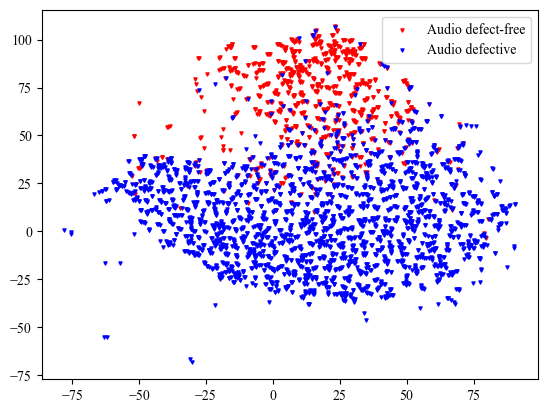

In [69]:
plt.scatter(X_embedded_normal_AE[:,0],X_embedded_normal_AE[:,1],s=5,c='r',marker='v')
plt.scatter(X_embedded_abnormal_AE[:,0],X_embedded_abnormal_AE[:,1],s=5,c='b',marker='v')
# plt.scatter(X_embedded_normal_IM[:,0],X_embedded_normal_IM[:,1],s=5,c='r')
# plt.scatter(X_embedded_abnormal_IM[:,0],X_embedded_abnormal_IM[:,1],s=5,c='b')
plt.legend(['Audio defect-free','Audio defective'])#,'Image non-defective','Image defective'
plt.savefig('CCSA_encoded_together_IMselect_AEonly.svg')

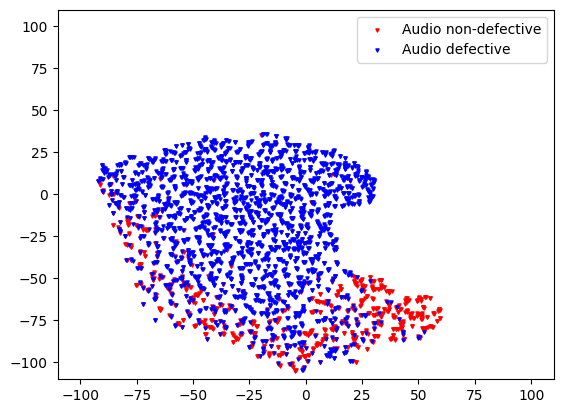

In [198]:
plt.scatter(X_embedded_normal_AE[:,0],X_embedded_normal_AE[:,1],s=5,c='r',marker='v')
plt.scatter(X_embedded_abnormal_AE[:,0],X_embedded_abnormal_AE[:,1],s=5,c='b',marker='v')
plt.xlim([-110,110])
plt.ylim([-110,110])
plt.legend(['Audio non-defective','Audio defective'])
# plt.savefig('CCSA_encoded_AE.svg')

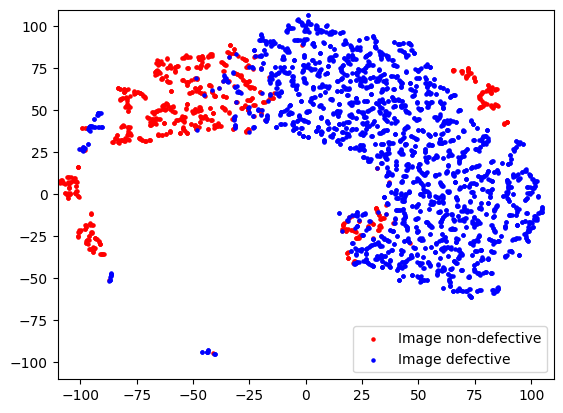

In [199]:
plt.scatter(X_embedded_normal_IM[:,0],X_embedded_normal_IM[:,1],s=5,c='r')
plt.scatter(X_embedded_abnormal_IM[:,0],X_embedded_abnormal_IM[:,1],s=5,c='b')
plt.xlim([-110,110])
plt.ylim([-110,110])
plt.legend(['Image non-defective','Image defective'])
# plt.savefig('CCSA_encoded_IM.svg')

In [114]:
X_embedded_normal_AE.shape

(1758, 2)

In [ ]:
learning_rate = 'auto'#0.1
init = 'random'
tsne = TSNE(n_components=2, learning_rate=learning_rate,init=init, perplexity=3)
X_concat = np.concatenate((X_test_target,X_val_source),0)
length = len(X_concat)

test_set = torch.tensor(X_concat, dtype=torch.float32).unsqueeze(0).view(length,1,80,80).to(device)
code = FE.forward(test_set) # Get the code through the feature extractor
#     print(torch.mean(code), torch.max(code), torch.min(code))
result1 = torch.round(TC.forward(code).cpu())
X_embedded = tsne.fit_transform(code.cpu().detach().numpy())

In [103]:
normal_AE

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')

# Fine-tuning the classifier

In [54]:
def train(encoder_network,task_network,device, target_train_loader, classifier_optim):
    utility()
    encoder_network.eval()
    task_network.train()
    # Other hyperparameters
    EPS = 1e-8 # A very small number
    margin = 1 # margin between normal and abnormal classes
    gamma = 0.5 # Weight between the classification and contrastive losses
    for batch in target_train_loader:
        target_batch = batch

        target_images, target_labels = target_batch['image'].cuda(), target_batch['label'].cuda()

        encoder_network.zero_grad()
        task_network.zero_grad()
        
        weight_negative = 3  # Weight for class 0 (negative class)
        weight_positive = 1  # Weight for class 1 (positive class)
        weights = torch.full_like(target_labels, weight_negative)  # Initialize weights with weight for class 0
        weights[target_labels == 1] = weight_positive  # Assign weight for class 1 where target is 1
        criterion = torch.nn.BCELoss(weights)

        #  Updating task classifer (TC)
        enc_target = encoder_network(target_images)
        target_output = task_network(enc_target)
        task_loss = criterion(target_output.view(len(target_output),1), target_labels.view(len(target_labels),1))#L_C classification loss to update task network

        task_loss.backward()#retain_graph=True
        classifier_optim.step()
    return task_loss

def evaluate(encoder_network,task_network, device, target_val_loader):
    encoder_network.eval()
    task_network.eval()
    correct = 0
    total = 0
    f1s = 0
    iters = 0
    with torch.no_grad():
         for batch in target_val_loader:
            data, target = batch['image'].cuda(), batch['label'].to(device)
            n_target = len(target)
            code = encoder_network.forward(data)
            output = task_network.forward(code)
            output = output.view(target.size(0))
            target = target.view(target.size(0))
            iters += 1
#             f1s += F1(target,output)
            accuracy = 1-torch.sum(torch.abs(target-torch.round(output)))/n_target
            f1s += accuracy
    return f1s / iters

In [55]:
# Define the objective function for Optuna
def objective(trial):
    
    lr = trial.suggest_float("lr", 1e-10, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-9, 1e-2)
#     alpha = trial.suggest_float('alpha', 1, 5)
    
    
    # model setups
    criterion_task = nn.BCELoss()
    criterion_disc = nn.BCEWithLogitsLoss()

    EPS = 1e-8
    epochs = 100
    utility()

    with open('CCSA_encoder.pkl', 'rb') as file:
        encoder_network = pickle.load(file)
    with open('CCSA_classifier.pkl', 'rb') as file:
        task_network = pickle.load(file)

#     encoder_optim = torch.optim.Adam(encoder_net.parameters(), lr=lr,weight_decay=weight_decay)
    classifier_optim = torch.optim.Adam(task_network.parameters(), lr=lr,weight_decay=weight_decay)
    
    for epoch in range(epochs):  # You can adjust the number of epochs
        train(encoder_network,task_network, device, train_loader_AE, classifier_optim)

    f1_score = evaluate(encoder_network,task_network, device, val_loader_AE)
    return f1_score

In [56]:
utility()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

print('Number of finished trials: ', len(study.trials))
print('Best trial:')
trial = study.best_trial

print('Value: ', trial.value)
print('Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')

[I 2024-04-18 10:40:26,452] A new study created in memory with name: no-name-5cf37e20-7b45-4d7a-9a14-00a244a1c8e8
[I 2024-04-18 10:40:37,190] Trial 0 finished with value: 0.9066406488418579 and parameters: {'lr': 0.0002921114539016623, 'weight_decay': 0.009473316366207685}. Best is trial 0 with value: 0.9066406488418579.
[I 2024-04-18 10:40:47,832] Trial 1 finished with value: 0.9367969036102295 and parameters: {'lr': 1.1984636090389575e-08, 'weight_decay': 0.00892666900167433}. Best is trial 1 with value: 0.9367969036102295.
[I 2024-04-18 10:40:58,405] Trial 2 finished with value: 0.9367969036102295 and parameters: {'lr': 2.4179574954697166e-08, 'weight_decay': 0.0010414451452857528}. Best is trial 1 with value: 0.9367969036102295.
[I 2024-04-18 10:41:09,210] Trial 3 finished with value: 0.9367969036102295 and parameters: {'lr': 9.891613056548794e-09, 'weight_decay': 0.0035723968174563112}. Best is trial 1 with value: 0.9367969036102295.
[I 2024-04-18 10:41:19,672] Trial 4 finished wi

[I 2024-04-18 10:47:24,759] Trial 39 finished with value: 0.9144531488418579 and parameters: {'lr': 0.00020828350025092377, 'weight_decay': 0.008138689303450799}. Best is trial 12 with value: 0.9417968988418579.
[I 2024-04-18 10:47:35,264] Trial 40 finished with value: 0.9135937690734863 and parameters: {'lr': 0.0006143428120471552, 'weight_decay': 0.006927077841471363}. Best is trial 12 with value: 0.9417968988418579.
[I 2024-04-18 10:47:45,757] Trial 41 finished with value: 0.9417968988418579 and parameters: {'lr': 1.753250011732144e-05, 'weight_decay': 0.007514168444814701}. Best is trial 12 with value: 0.9417968988418579.
[I 2024-04-18 10:47:56,386] Trial 42 finished with value: 0.9367969036102295 and parameters: {'lr': 2.691061974038371e-06, 'weight_decay': 0.002575194301989183}. Best is trial 12 with value: 0.9417968988418579.
[I 2024-04-18 10:48:06,948] Trial 43 finished with value: 0.9398437738418579 and parameters: {'lr': 3.963199396156913e-05, 'weight_decay': 0.00617684925527

[I 2024-04-18 10:54:15,285] Trial 78 finished with value: 0.9367969036102295 and parameters: {'lr': 3.72611113093541e-06, 'weight_decay': 0.008040662364655463}. Best is trial 49 with value: 0.9437500238418579.
[I 2024-04-18 10:54:25,678] Trial 79 finished with value: 0.9367969036102295 and parameters: {'lr': 6.020547970894126e-07, 'weight_decay': 0.006686429093534266}. Best is trial 49 with value: 0.9437500238418579.
[I 2024-04-18 10:54:36,050] Trial 80 finished with value: 0.9242187738418579 and parameters: {'lr': 9.448261726774292e-05, 'weight_decay': 0.008964038099783656}. Best is trial 49 with value: 0.9437500238418579.
[I 2024-04-18 10:54:46,427] Trial 81 finished with value: 0.9417968988418579 and parameters: {'lr': 7.860360600646348e-06, 'weight_decay': 0.006911460252956256}. Best is trial 49 with value: 0.9437500238418579.
[I 2024-04-18 10:54:56,877] Trial 82 finished with value: 0.9417968988418579 and parameters: {'lr': 1.9502710143847576e-05, 'weight_decay': 0.007662240390755

[I 2024-04-18 11:01:02,252] Trial 117 finished with value: 0.9387500286102295 and parameters: {'lr': 2.5356054075284926e-05, 'weight_decay': 8.314662939397019e-05}. Best is trial 49 with value: 0.9437500238418579.
[I 2024-04-18 11:01:12,906] Trial 118 finished with value: 0.9367969036102295 and parameters: {'lr': 2.640021404205297e-06, 'weight_decay': 0.006403924955885392}. Best is trial 49 with value: 0.9437500238418579.
[I 2024-04-18 11:01:23,448] Trial 119 finished with value: 0.9417968988418579 and parameters: {'lr': 9.712266039489949e-06, 'weight_decay': 0.00884689973018262}. Best is trial 49 with value: 0.9437500238418579.
[I 2024-04-18 11:01:33,963] Trial 120 finished with value: 0.9339843988418579 and parameters: {'lr': 7.184107343793251e-05, 'weight_decay': 0.007824864427722084}. Best is trial 49 with value: 0.9437500238418579.
[I 2024-04-18 11:01:44,570] Trial 121 finished with value: 0.9417968988418579 and parameters: {'lr': 1.5658219110332723e-05, 'weight_decay': 0.00755271

KeyboardInterrupt: 

In [67]:
EPS = 1e-8
epochs = 200
utility()

# encoder_optim = torch.optim.Adam(encoder_net.parameters(), lr=0.0004446418669287182,weight_decay=0.0007849821705708979)
classifier_optim = torch.optim.Adam(task_network.parameters(), lr=2.9917513678349753e-05,weight_decay=0.0068145599560912595)


task_rec1 = []
for epoch in range(epochs):  # You can adjust the number of epochs
    print(epoch)
    task_ls = train(encoder_network,task_network, device,  train_loader_AE, classifier_optim)
    task_loss = task_ls.cpu().detach().numpy()
    task_rec1.append(task_loss)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199


Text(0.5, 1.0, 'Loss curve')

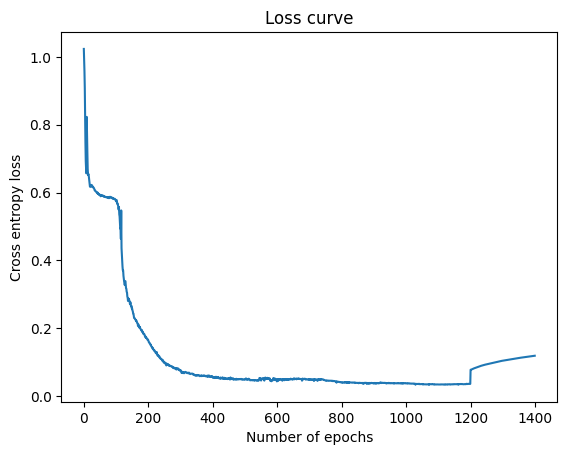

In [68]:
plt.plot(task_rec+task_rec1)
plt.xlabel('Number of epochs')
plt.ylabel('Cross entropy loss')
plt.title('Loss curve')

In [69]:
evaluate(encoder_network,task_network,device, train_loader_AE)

tensor(0.9316, device='cuda:0')

In [70]:
evaluate(encoder_network,task_network,device, val_loader_AE)

tensor(0.9403, device='cuda:0')

In [71]:
evaluate(encoder_network,task_network,device, test_loader_AE)

tensor(0.9238, device='cuda:0')

In [43]:
torch.autograd.set_detect_anomaly(True)

# Other hyperparameters
EPS = 1e-8 # A very small number
margin = 1 # margin between normal and abnormal classes
gamma = 0.5 # Weight between the classification and contrastive losses
epochs = 1000 # number of epochs

encoder_net = SharedConvNet().cuda() # Convolutional encoder that builds a common encoded space
task_net = ClassifierNet(num_classes=n_class).cuda() # Task classifier that classifies abnormal and normal melt pools based on the encoded features

# Defining the optimizerr for respective networks
encoder_optim = torch.optim.Adam(encoder_net.parameters(), lr=0.1)
classifier_optim =torch.optim.Adam(task_net.parameters(), lr=0.1)

CE_loss = []
TC_loss = []
SA_loss = []

# To save loss curves
for epoch in range(epochs):
    encoder_net.train()
    task_net.train()
    n_batch = 0
    CE_loss_ = 0
    TC_loss_ = 0
    SA_loss_ = 0

    for batch in zip(train_loader_IM, train_loader_AE):#source_train_loader, target_train_loader
        encoder_optim.zero_grad()
        classifier_optim.zero_grad()
        
        # Read from a batch
        source_batch, target_batch = batch

        source_images, source_labels = source_batch['image'].cuda(), source_batch['label'].cuda()
        target_images, target_labels = target_batch['image'].cuda(), target_batch['label'].cuda()
        
        weight_negative = 3  # Weight for class 0 (negative class)
        weight_positive = 1  # Weight for class 1 (positive class)
        weights = torch.full_like(source_labels, weight_negative)  # Initialize weights with weight for class 0
        weights[source_labels == 1] = weight_positive  # Assign weight for class 1 where target is 1
        criterion = torch.nn.BCELoss(weights)
        
        if source_labels.dim() <= 1 or source_labels.size(1) == 1:
            source_labels_is_1d = True
        else:
            source_labels_is_1d = False

        # # Updating Convolutional encoder (CE)
        enc_source = encoder_net(source_images)
        enc_target = encoder_net(target_images)

        source_output = task_net(enc_source)
        target_output = task_net(enc_target)
        
        task_loss = criterion(source_output.view(len(source_output),1), source_labels.view(len(source_labels),1))#L_C classification loss to update task network
        task_loss += criterion(target_output.view(len(target_output),1), target_labels.view(len(target_labels),1))#L_C classification loss to update task network
        task_loss = task_loss/2
        dist_y = pairwise_y(source_labels, target_labels)            
        dist_X = pairwise_X(enc_source, enc_target)
        
        if source_labels_is_1d:
            dist_y *= 2
            
        contrastive_loss = torch.sum(dist_y * torch.maximum(torch.tensor(0.0), margin - dist_X), 1) / (torch.sum(dist_y, 1) + EPS)
        contrastive_loss += torch.sum((1 - dist_y) * dist_X, 1) / (torch.sum(1 - dist_y, 1) + EPS)
        contrastive_loss = torch.mean(contrastive_loss)
        contrastive_loss *= 0.5
        
#         target_loss = criterion(target_output, target_labels)
        enc_loss = gamma*task_loss + (1-gamma)*contrastive_loss#task_loss + gamma*contrastive_loss #L_CCSA = L_C + L_SA + L_S
        enc_loss.backward()#retain_graph=True
        encoder_optim.step()   
        CE_loss_ += enc_loss.item()
        SA_loss_ += contrastive_loss.item()
        
        #  Updating task classifer (TC)
        enc_source = encoder_net(source_images)
        enc_target = encoder_net(target_images)

        source_output = task_net(enc_source)
        target_output = task_net(enc_target)
        
        task_loss = criterion(source_output.view(len(source_output),1), source_labels.view(len(source_labels),1))#L_C classification loss to update task network
        task_loss += criterion(target_output.view(len(target_output),1), target_labels.view(len(target_labels),1))#L_C classification loss to update task network
        task_loss = task_loss/2
        task_loss.backward()#retain_graph=True
        classifier_optim.step()
        TC_loss_ += task_loss.item()
        
        
        n_batch += 1
        
    CE_loss.append(CE_loss_/n_batch)
    TC_loss.append(TC_loss_/n_batch)
    SA_loss.append(SA_loss_/n_batch)

        

    print(f'Epoch [{epoch+1}/{epochs}], Total Loss: {SA_loss_/n_batch}, TC Loss: {TC_loss_/n_batch}, FE Loss: {CE_loss_/n_batch}',n_batch)

# Save or use the model as needed
torch.save(model.state_dict(), 'my_model.pth')

Epoch [1/1000], Total Loss: 1032.7204113006592, TC Loss: 1.168833076953888, FE Loss: 516.9402438913073 28
Epoch [2/1000], Total Loss: 12.963011111531939, TC Loss: 1.0030977704695292, FE Loss: 6.982954144477844 28
Epoch [3/1000], Total Loss: 6.640578644616263, TC Loss: 0.9910401850938797, FE Loss: 3.815780060631888 28
Epoch [4/1000], Total Loss: 4.517508625984192, TC Loss: 0.9854745141097477, FE Loss: 2.75147499356951 28
Epoch [5/1000], Total Loss: 3.4528063535690308, TC Loss: 0.9965520586286273, FE Loss: 2.22466898390225 28
Epoch [6/1000], Total Loss: 2.835984102317265, TC Loss: 0.9886800199747086, FE Loss: 1.9123309084347315 28
Epoch [7/1000], Total Loss: 2.3525465769427165, TC Loss: 0.9922334062201636, FE Loss: 1.6723883279732294 28
Epoch [8/1000], Total Loss: 1.9808655551501684, TC Loss: 0.9844023542744773, FE Loss: 1.4826361281531197 28
Epoch [9/1000], Total Loss: 1.7355406965528215, TC Loss: 0.9816883440528598, FE Loss: 1.3586132185799735 28
Epoch [10/1000], Total Loss: 1.53816533

Epoch [77/1000], Total Loss: 0.5259979920727866, TC Loss: 0.9585665592125484, FE Loss: 0.7424179741314479 28
Epoch [78/1000], Total Loss: 0.5214468113013676, TC Loss: 0.9520909147603172, FE Loss: 0.7371849524123328 28
Epoch [79/1000], Total Loss: 0.521718082683427, TC Loss: 0.9085065168993813, FE Loss: 0.716489138347762 28
Epoch [80/1000], Total Loss: 0.5222411453723907, TC Loss: 0.9839894494840077, FE Loss: 0.7550788564341409 28
Epoch [81/1000], Total Loss: 0.5278329338346209, TC Loss: 1.0185481756925583, FE Loss: 0.7731905558279583 28
Epoch [82/1000], Total Loss: 0.5212868068899427, TC Loss: 0.9880358534199851, FE Loss: 0.754661330154964 28
Epoch [83/1000], Total Loss: 0.5283732478107724, TC Loss: 0.9931336641311646, FE Loss: 0.7607534527778625 28
Epoch [84/1000], Total Loss: 0.5159284834350858, TC Loss: 0.9871797519070762, FE Loss: 0.7515541272503989 28
Epoch [85/1000], Total Loss: 0.5121618509292603, TC Loss: 0.9822130011660712, FE Loss: 0.7471874271120343 28
Epoch [86/1000], Total

Epoch [152/1000], Total Loss: 0.4330251621348517, TC Loss: 0.9829839787312916, FE Loss: 0.7080045683043343 28
Epoch [153/1000], Total Loss: 0.4535064750484058, TC Loss: 0.9849754742213658, FE Loss: 0.7192409719739642 28
Epoch [154/1000], Total Loss: 0.43587510607072283, TC Loss: 0.9831627032586506, FE Loss: 0.7095189094543457 28
Epoch [155/1000], Total Loss: 0.43408780438559397, TC Loss: 0.9818885752132961, FE Loss: 0.7079881876707077 28
Epoch [156/1000], Total Loss: 0.4219436602933066, TC Loss: 0.9817242622375488, FE Loss: 0.7018339591366904 28
Epoch [157/1000], Total Loss: 0.4276194434080805, TC Loss: 0.9844998014824731, FE Loss: 0.7060596261705671 28
Epoch [158/1000], Total Loss: 0.4180347238268171, TC Loss: 0.9800939453499657, FE Loss: 0.69906433565276 28
Epoch [159/1000], Total Loss: 0.41511451240096775, TC Loss: 0.9892193632466453, FE Loss: 0.7021669362272535 28
Epoch [160/1000], Total Loss: 0.41763766961438314, TC Loss: 0.987685848559652, FE Loss: 0.702661761215755 28
Epoch [161

Epoch [227/1000], Total Loss: 0.35554323345422745, TC Loss: 0.9787431848900658, FE Loss: 0.6671432086399623 28
Epoch [228/1000], Total Loss: 0.5382369682192802, TC Loss: 0.97573535995824, FE Loss: 0.7569861582347325 28
Epoch [229/1000], Total Loss: 0.37321378184216364, TC Loss: 0.9786964463336127, FE Loss: 0.6759551146200725 28
Epoch [230/1000], Total Loss: 0.35666607533182415, TC Loss: 0.9903918206691742, FE Loss: 0.6735289480004992 28
Epoch [231/1000], Total Loss: 0.4300316497683525, TC Loss: 0.992426376257624, FE Loss: 0.7112290135451725 28
Epoch [232/1000], Total Loss: 0.3486768337232726, TC Loss: 0.9865227128778186, FE Loss: 0.6675997738327298 28
Epoch [233/1000], Total Loss: 0.3504581930381911, TC Loss: 0.9838674579347882, FE Loss: 0.667162822825568 28
Epoch [234/1000], Total Loss: 0.36526759394577574, TC Loss: 0.9804891624620983, FE Loss: 0.6728783824614116 28
Epoch [235/1000], Total Loss: 0.347476241844041, TC Loss: 0.9862520907606397, FE Loss: 0.6668641716241837 28
Epoch [236/

Epoch [302/1000], Total Loss: 0.3052509278059006, TC Loss: 0.9900376711572919, FE Loss: 0.647644294159753 28
Epoch [303/1000], Total Loss: 0.31428082500185284, TC Loss: 0.9777771000351224, FE Loss: 0.6460289593253817 28
Epoch [304/1000], Total Loss: 0.30745831025498255, TC Loss: 0.986036132488932, FE Loss: 0.6467472229685102 28
Epoch [305/1000], Total Loss: 0.3053183619465147, TC Loss: 0.9866875729390553, FE Loss: 0.6460029631853104 28
Epoch [306/1000], Total Loss: 0.2934795192309788, TC Loss: 0.9821239177669797, FE Loss: 0.6378017174346107 28
Epoch [307/1000], Total Loss: 0.30849565991333555, TC Loss: 0.9866801521607808, FE Loss: 0.6475879081657955 28
Epoch [308/1000], Total Loss: 0.30953559811626163, TC Loss: 0.9852003519024167, FE Loss: 0.6473679797989982 28
Epoch [309/1000], Total Loss: 0.3037031314202717, TC Loss: 0.9827967307397297, FE Loss: 0.6432499353374753 28
Epoch [310/1000], Total Loss: 0.302970251334565, TC Loss: 0.9901646333081382, FE Loss: 0.6465674489736557 28
Epoch [31

...

Epoch [677/1000], Total Loss: 0.2934212418539183, TC Loss: 0.9848049836499351, FE Loss: 0.6391131090266364 28
Epoch [678/1000], Total Loss: 0.2932973823377064, TC Loss: 0.9911348990031651, FE Loss: 0.6422161396060672 28
Epoch [679/1000], Total Loss: 0.27547075918742586, TC Loss: 0.9790597600596291, FE Loss: 0.6272652617522648 28
Epoch [680/1000], Total Loss: 0.27891736903360914, TC Loss: 0.9890997814280647, FE Loss: 0.6340085715055466 28
Epoch [681/1000], Total Loss: 0.2851417761828218, TC Loss: 0.9780014476605824, FE Loss: 0.6315716089946883 28
Epoch [682/1000], Total Loss: 0.2795616223343781, TC Loss: 0.9843580254486629, FE Loss: 0.6319598321403775 28
Epoch [683/1000], Total Loss: 0.27985470635550364, TC Loss: 0.9901267311402729, FE Loss: 0.6349907240697316 28
Epoch [684/1000], Total Loss: 0.28015168543372837, TC Loss: 0.9843170302254813, FE Loss: 0.6322343604905265 28
Epoch [685/1000], Total Loss: 0.2722126969269344, TC Loss: 0.997519891176905, FE Loss: 0.6348662993737629 28
Epoch [

Epoch [752/1000], Total Loss: 0.2617986814251968, TC Loss: 0.9898785523005894, FE Loss: 0.6258386203220913 28
Epoch [753/1000], Total Loss: 0.2493633824799742, TC Loss: 0.9767831500087466, FE Loss: 0.613073257463319 28
Epoch [754/1000], Total Loss: 0.255435407693897, TC Loss: 0.989393066082682, FE Loss: 0.6224142334290913 28
Epoch [755/1000], Total Loss: 0.25921009108424187, TC Loss: 0.9815949925354549, FE Loss: 0.6204025404793876 28
Epoch [756/1000], Total Loss: 0.26662775448390413, TC Loss: 0.9819929642336709, FE Loss: 0.6243103614875248 28
Epoch [757/1000], Total Loss: 0.2645764888397285, TC Loss: 0.973304767693792, FE Loss: 0.6189406322581428 28
Epoch [758/1000], Total Loss: 0.25843885487743784, TC Loss: 0.9871701917478016, FE Loss: 0.6228045289005552 28
Epoch [759/1000], Total Loss: 0.2609261061464037, TC Loss: 0.9844644346407482, FE Loss: 0.6226952650717327 28
Epoch [760/1000], Total Loss: 0.26248654403856825, TC Loss: 0.9893329654421125, FE Loss: 0.6259097584656307 28
Epoch [761

Epoch [827/1000], Total Loss: 0.23789031218205178, TC Loss: 0.9987121522426605, FE Loss: 0.6183022196803775 28
Epoch [828/1000], Total Loss: 0.2329049887401717, TC Loss: 0.9818992210286004, FE Loss: 0.6074021096740451 28
Epoch [829/1000], Total Loss: 0.2402514996273177, TC Loss: 0.9781974426337651, FE Loss: 0.6092244663408825 28
Epoch [830/1000], Total Loss: 0.23834424146584102, TC Loss: 0.9791513404675892, FE Loss: 0.6087477909667152 28
Epoch [831/1000], Total Loss: 0.23601159932357924, TC Loss: 0.9762073627540043, FE Loss: 0.6061094871589116 28
Epoch [832/1000], Total Loss: 0.23268122598528862, TC Loss: 0.9872708001307079, FE Loss: 0.6099760106631688 28
Epoch [833/1000], Total Loss: 0.23824557395918028, TC Loss: 0.9763428334678922, FE Loss: 0.6072941986577851 28
Epoch [834/1000], Total Loss: 0.2377807056265218, TC Loss: 0.9820882486445563, FE Loss: 0.6099344768694469 28
Epoch [835/1000], Total Loss: 0.23466610722243786, TC Loss: 0.9755694781030927, FE Loss: 0.6051177872078759 28
Epoc

Epoch [902/1000], Total Loss: 0.20854004871632373, TC Loss: 0.9745221116713115, FE Loss: 0.5915316215583256 28
Epoch [903/1000], Total Loss: 0.21904648414679936, TC Loss: 0.9832629667861121, FE Loss: 0.6011547297239304 28
Epoch [904/1000], Total Loss: 0.22107038167970522, TC Loss: 0.9909184468644006, FE Loss: 0.6059944118772235 28
Epoch [905/1000], Total Loss: 0.2154388502240181, TC Loss: 0.9895686379500798, FE Loss: 0.6025037403617587 28
Epoch [906/1000], Total Loss: 0.20909798677478517, TC Loss: 0.9884506740740368, FE Loss: 0.598774328827858 28
Epoch [907/1000], Total Loss: 0.21308188353266036, TC Loss: 0.9916995125157493, FE Loss: 0.6023907044104168 28
Epoch [908/1000], Total Loss: 0.21212138129132135, TC Loss: 0.9930731526442936, FE Loss: 0.6025972664356232 28
Epoch [909/1000], Total Loss: 0.2502997842218195, TC Loss: 0.985390727009092, FE Loss: 0.6178452564137322 28
Epoch [910/1000], Total Loss: 0.22396610251494817, TC Loss: 0.9771679661103657, FE Loss: 0.600567031119551 28
Epoch 

Epoch [977/1000], Total Loss: 0.20415594588432992, TC Loss: 0.9851380799497876, FE Loss: 0.5946470137153353 28
Epoch [978/1000], Total Loss: 0.20283628042255128, TC Loss: 0.979190992457526, FE Loss: 0.5910136348434857 28
Epoch [979/1000], Total Loss: 0.20875368426953042, TC Loss: 0.9748895977224622, FE Loss: 0.5918216407299042 28
Epoch [980/1000], Total Loss: 0.19958436435886792, TC Loss: 0.9853759173836026, FE Loss: 0.5924801379442215 28
Epoch [981/1000], Total Loss: 0.22048826781766756, TC Loss: 0.981577490057264, FE Loss: 0.601032880800111 28
Epoch [982/1000], Total Loss: 0.20725752040743828, TC Loss: 0.9855767999376569, FE Loss: 0.5964171588420868 28
Epoch [983/1000], Total Loss: 0.19383082113095693, TC Loss: 0.9940848967858723, FE Loss: 0.593957856297493 28
Epoch [984/1000], Total Loss: 0.21182025649717875, TC Loss: 1.0015696244580405, FE Loss: 0.6066949399454253 28
Epoch [985/1000], Total Loss: 0.2062661764877183, TC Loss: 0.9874758613961083, FE Loss: 0.596871018409729 28
Epoch [

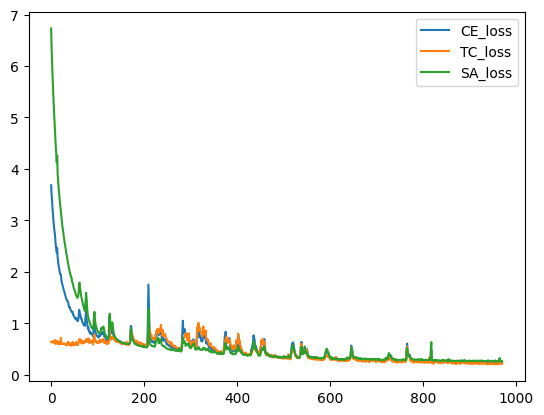

In [39]:
plt.plot(CE_loss[30:])
plt.plot(TC_loss[30:])
plt.plot(SA_loss[30:])
plt.legend(['CE_loss','TC_loss','SA_loss'])

In [ ]:
plt.plot(CE_loss[30:])
plt.plot(TC_loss[30:])
plt.plot(SA_loss[30:])
plt.legend(['CE_loss','TC_loss','SA_loss'])

In [40]:
evaluate(device, train_loader_AE)

tensor(0.9369, device='cuda:0')

In [41]:
evaluate(device, val_loader_AE)

tensor(0.9225, device='cuda:0')

In [42]:
evaluate(device, test_loader_AE)

tensor(0.9012, device='cuda:0')

In [225]:
offset = -0.0

In [219]:
evaluate(y_train_source,X_train_source,offset)

Length of dataset 3750
tensor(0.4167, device='cuda:0', grad_fn=<MeanBackward0>)
Predicted as 1 tensor(1707., grad_fn=<SumBackward0>)
Wrong predictions tensor(235., grad_fn=<SumBackward0>)
Accuracy tensor(0.9373, grad_fn=<RsubBackward1>)
F1 tensor(0.9347)
tensor(0.5024, grad_fn=<RsubBackward1>)


In [220]:
evaluate(y_val_source,X_val_source,offset)

Length of dataset 100
tensor(0.4182, device='cuda:0', grad_fn=<MeanBackward0>)
Predicted as 1 tensor(71., grad_fn=<SumBackward0>)
Wrong predictions tensor(33., grad_fn=<SumBackward0>)
Accuracy tensor(0.6700, grad_fn=<RsubBackward1>)
F1 tensor(0.7273)
tensor(0.5377, grad_fn=<RsubBackward1>)


In [221]:
evaluate(y_train_target,X_train_target,offset)

Length of dataset 4000
tensor(0.4165, device='cuda:0', grad_fn=<MeanBackward0>)
Predicted as 1 tensor(739., grad_fn=<SumBackward0>)
Wrong predictions tensor(1307., grad_fn=<SumBackward0>)
Accuracy tensor(0.6732, grad_fn=<RsubBackward1>)
F1 tensor(0.5228)
tensor(0.5073, grad_fn=<RsubBackward1>)


In [222]:
evaluate(y_val_target,X_val_target,offset)

Length of dataset 100
tensor(0.4165, device='cuda:0', grad_fn=<MeanBackward0>)
Predicted as 1 tensor(78., grad_fn=<SumBackward0>)
Wrong predictions tensor(50., grad_fn=<SumBackward0>)
Accuracy tensor(0.5000, grad_fn=<RsubBackward1>)
F1 tensor(0.6094)
tensor(0.6177, grad_fn=<RsubBackward1>)


In [223]:
evaluate(y_test_target,X_test_target,offset)

Length of dataset 100
tensor(0.4165, device='cuda:0', grad_fn=<MeanBackward0>)
Predicted as 1 tensor(49., grad_fn=<SumBackward0>)
Wrong predictions tensor(57., grad_fn=<SumBackward0>)
Accuracy tensor(0.4300, grad_fn=<RsubBackward1>)
F1 tensor(0.4242)
tensor(0.5555, grad_fn=<RsubBackward1>)


In [224]:
n_test = 100
testset = torch.tensor(X_test_source, dtype=torch.float32).unsqueeze(0).view(n_test,1,80,80).to(device)

In [90]:
result = task_net.forward(encoder_net.forward(testset)).cpu()
test_labs = torch.tensor(y_test_source, dtype=torch.float32).view(n_test,1)
print(torch.sum(torch.round(result)))
print(torch.sum(torch.abs(test_labs-torch.round(result))))
print(1-torch.sum(torch.abs(test_labs-torch.round(result)))/len(test_labs))
F1(torch.round(result).view(n_test,),test_labs.view(n_test,))

tensor(81., grad_fn=<SumBackward0>)
tensor(33., grad_fn=<SumBackward0>)
tensor(0.6700, grad_fn=<RsubBackward1>)


tensor(0.7481)

In [247]:
n_test = 100
testset = torch.tensor(X_test_target, dtype=torch.float32).unsqueeze(0).view(n_test,1,80,80).to(device)

In [248]:
result = task_net.forward(encoder_net.forward(testset)).cpu()
test_labs = torch.tensor(y_test_target, dtype=torch.float32).view(n_test,1)
print(torch.sum(torch.round(result)))
print(torch.sum(torch.abs(test_labs-torch.round(result))))
print(1-torch.sum(torch.abs(test_labs-torch.round(result)))/len(test_labs))
F1(torch.round(result).view(n_test,),test_labs.view(n_test,))

tensor(100., grad_fn=<SumBackward0>)
tensor(50., grad_fn=<SumBackward0>)
tensor(0.5000, grad_fn=<RsubBackward1>)


tensor(0.6667)

In [249]:
n_test = 200
testset = torch.tensor(X_train_target, dtype=torch.float32).unsqueeze(0).view(n_test,1,80,80).to(device)

In [250]:
result = task_net.forward(encoder_net.forward(testset)).cpu()
test_labs = torch.tensor(y_train_target, dtype=torch.float32).view(n_test,1)
print(torch.sum(torch.round(result)))
print(torch.sum(torch.abs(test_labs-torch.round(result))))
print(1-torch.sum(torch.abs(test_labs-torch.round(result)))/len(test_labs))
F1(torch.round(result).view(n_test,),test_labs.view(n_test,))

tensor(200., grad_fn=<SumBackward0>)
tensor(100., grad_fn=<SumBackward0>)
tensor(0.5000, grad_fn=<RsubBackward1>)


tensor(0.6667)

In [123]:
result

tensor([[0.9894],
        [0.9902],
        [0.9856],
        [0.9859],
        [0.9872],
        [0.9902],
        [0.9877],
        [0.9849],
        [0.9842],
        [0.9880],
        [0.9869],
        [0.9886],
        [0.9862],
        [0.9877],
        [0.9906],
        [0.9912],
        [0.9889],
        [0.9905],
        [0.9898],
        [0.9888],
        [0.9876],
        [0.9882],
        [0.9856],
        [0.9910],
        [0.9896],
        [0.9892],
        [0.9911],
        [0.9847],
        [0.9867],
        [0.9892],
        [0.9907],
        [0.9897],
        [0.9950],
        [0.9950],
        [0.9916],
        [0.9939],
        [0.9939],
        [0.9905],
        [0.9895],
        [0.9941],
        [0.9949],
        [0.9938],
        [0.9902],
        [0.9944],
        [0.9961],
        [0.9974],
        [0.9840],
        [0.9812],
        [0.9817],
        [0.9881],
        [0.9874],
        [0.9883],
        [0.9851],
        [0.9781],
        [0.9828],
        [0

In [121]:
X_train_target.shape

(40, 80, 80)

In [138]:
img = Image.fromarray(np.uint8(X_val_target[75,:,:]*255), 'L')
img.show()

In [143]:
zoom_factor = 2.5
img = Image.fromarray(np.uint8(X_val_target[79,:,:]*255), 'L')
new_width = int(img.width * zoom_factor)
new_height = int(img.height * zoom_factor)
zoomed_image = img.resize((new_width, new_height))
zoomed_image.show()

In [144]:
zoomed_image.size

(200, 200)

In [135]:
y_test_target

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],

In [149]:
torch.autograd.set_detect_anomaly(True)

EPS = 1e-8
margin = 1
gamma = 0.95
epochs = 10

encoder_net = SharedConvNet().cuda()
task_net = ClassifierNet(num_classes=n_class).cuda()

encoder_optim = torch.optim.Adam(encoder_net.parameters(), lr=0.0001)
classifier_optim =torch.optim.Adam(encoder_net.parameters(), lr=0.0001)



for epoch in range(epochs):
    encoder_net.train()
    task_net.train()


    for batch in zip(source_train_loader, target_train_loader):
        encoder_optim.zero_grad()
        classifier_optim.zero_grad()
        source_batch, target_batch = batch

        source_images, source_labels = source_batch['image'].cuda(), source_batch['label'].cuda()
        target_images, target_labels = target_batch['image'].cuda(), target_batch['label'].cuda()
        if source_labels.dim() <= 1 or source_labels.size(1) == 1:
            source_labels_is_1d = True
        else:
            source_labels_is_1d = False

        # CE
        enc_source = encoder_net(source_images)
        enc_target = encoder_net(target_images)

        source_output = task_net(enc_source)
        
        task_loss = criterion(source_output.view(len(source_output),1), source_labels.view(len(source_labels),1))#L_C classification loss to update task network
    
        dist_y = pairwise_y(source_labels, target_labels)            
        dist_X = pairwise_X(enc_source, enc_target)
        
        if source_labels_is_1d:
            dist_y *= 2
            
        contrastive_loss = torch.sum(dist_y * torch.maximum(torch.tensor(0.0), margin - dist_X), 1) / (torch.sum(dist_y, 1) + EPS)
        contrastive_loss += torch.sum((1 - dist_y) * dist_X, 1) / (torch.sum(1 - dist_y, 1) + EPS)
        contrastive_loss = torch.mean(contrastive_loss)
        contrastive_loss *= 0.5
        
#         target_loss = criterion(target_output, target_labels)
        enc_loss = gamma*task_loss + (1-gamma)*contrastive_loss #L_CCSA = L_C + L_SA + L_S
        enc_loss.backward()
        encoder_optim.step()
        
        # Compute gradients
        trainable_vars_task = task_net.parameters()
        trainable_vars_enc = encoder_net.parameters()       
        gradients_task = torch.autograd.grad(task_loss, trainable_vars_task, retain_graph=True)
        gradients_enc = torch.autograd.grad(enc_loss, trainable_vars_enc, retain_graph=True)
        
        # Update weights
        with torch.no_grad():
            for param, grad in zip(trainable_vars_task, gradients_task):
                param -= self.optimizer.param_groups[0]['lr'] * grad

            for param, grad in zip(trainable_vars_enc, gradients_enc):
                param -= self.optimizer_enc.param_groups[0]['lr'] * grad
        

        # Combine losses with some weighting factor if needed
#         total_loss = source_loss + target_loss

        # Backward and optimize


        

    print(f'Epoch [{epoch+1}/{epochs}], Total Loss: {enc_loss.item()}, TC Loss: {task_loss.item()}, FE Loss: {contrastive_loss.item()}')

# Save or use the model as needed
torch.save(model.state_dict(), 'my_model.pth')

C:\Users\jiaru\.conda\envs\AM_MM\lib\site-packages\torch\autograd\__init__.py:394: UserWarning: Error detected in BinaryCrossEntropyBackward0. Traceback of forward call that caused the error:
  File "C:\Users\jiaru\.conda\envs\AM_MM\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\jiaru\.conda\envs\AM_MM\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\jiaru\.conda\envs\AM_MM\lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\jiaru\.conda\envs\AM_MM\lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\jiaru\.conda\envs\AM_MM\lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\jiaru\.conda\envs\AM_MM\lib\site-packages\tornado\platform\asyncio.py", line 195, in start
    self.asyncio_loop.run_forever()
  File "C:\Users\jiaru

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [46]:
torch.autograd.set_detect_anomaly(True)

EPS = 1e-8
margin = 1
gamma = 0

encoder_net = SharedConvNet().cuda()
task_net = ClassifierNet(num_classes=n_class).cuda()

encoder_optim = torch.optim.Adam(encoder_net.parameters(), lr=0.001)
classifier_optim =torch.optim.Adam(encoder_net.parameters(), lr=0.001)



for epoch in range(epochs):
    encoder_net.train()
    task_net.train()
    
    
    encoder_optim.zero_grad()
    classifier_optim.zero_grad()

    for batch in zip(source_train_loader, target_train_loader):
        source_batch, target_batch = batch

        source_images, source_labels = source_batch['image'].cuda(), source_batch['label'].cuda()
        target_images, target_labels = target_batch['image'].cuda(), target_batch['label'].cuda()
#         print(2)
        if source_labels.dim() <= 1 or source_labels.size(1) == 1:
            source_labels_is_1d = True
        else:
            source_labels_is_1d = False

        # Enc
        # Forward pass
        enc_source = encoder_net(source_images)
        enc_target = encoder_net(target_images)
        source_output = task_net(enc_source)
        
        # Calculate losses
        dist_y = pairwise_y(source_labels, target_labels)            
        dist_X = pairwise_X(enc_source, enc_target)
        
        if source_labels_is_1d:
            dist_y *= 2
            
        contrastive_loss = torch.sum(dist_y * torch.maximum(torch.tensor(0.0), margin - dist_X), 1) / (torch.sum(dist_y, 1) + EPS)
        contrastive_loss += torch.sum((1 - dist_y) * dist_X, 1) / (torch.sum(1 - dist_y, 1) + EPS)
        contrastive_loss = torch.mean(contrastive_loss)
        contrastive_loss *= 0.5
        
        task_loss = criterion(source_output, source_labels)#L_C classification loss to update task network
        enc_loss = gamma*task_loss + (1-gamma)*contrastive_loss #L_CCSA = L_C + L_SA + L_S
        
        enc_loss.backward()
        encoder_optim.step()

        # Task
        enc_source = encoder_net(source_images)
        source_output = task_net(enc_source)

        task_loss = criterion(source_output, source_labels)#L_C classification loss to update task network

        # Backward and optimize
        task_loss.backward()
        classifier_optim.step()
        
        

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {enc_loss.item()}')

# Save or use the model as needed
torch.save(model.state_dict(), 'my_model.pth')

TypeError: view(): argument 'size' failed to unpack the object at pos 2 with error "type must be tuple of ints,but got float"

In [293]:
# Lists to store training and validation losses for plotting
train_losses = []
val_losses = []

# Training loop with early stopping
for epoch in range(epochs):
    model.train()
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, data)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            outputs = model(data)
            val_loss += criterion(outputs, data).item()

    val_loss /= len(val_loader)

    # Check for early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping after {epoch+1} epochs.')
            break

    # Append the training and validation losses for plotting
    train_losses.append(loss.item())
    val_losses.append(val_loss)

    print(f'Epoch [{epoch+1}/{epochs}],Train_Loss: {loss.item():.4f}, Val_Loss: {val_loss:.4f}')

# Save the trained model
torch.save(model.state_dict(), 'autoencoder_model.pth')

Epoch [1/200],Train_Loss: 0.0068, Val_Loss: 0.0070
Epoch [2/200],Train_Loss: 0.0025, Val_Loss: 0.0025
Epoch [3/200],Train_Loss: 0.0014, Val_Loss: 0.0014
Epoch [4/200],Train_Loss: 0.0010, Val_Loss: 0.0010
Epoch [5/200],Train_Loss: 0.0008, Val_Loss: 0.0008
Epoch [6/200],Train_Loss: 0.0007, Val_Loss: 0.0006
Epoch [7/200],Train_Loss: 0.0005, Val_Loss: 0.0005
Epoch [8/200],Train_Loss: 0.0005, Val_Loss: 0.0005
Epoch [9/200],Train_Loss: 0.0004, Val_Loss: 0.0004
Epoch [10/200],Train_Loss: 0.0004, Val_Loss: 0.0004
Epoch [11/200],Train_Loss: 0.0004, Val_Loss: 0.0004
Epoch [12/200],Train_Loss: 0.0004, Val_Loss: 0.0003
Epoch [13/200],Train_Loss: 0.0003, Val_Loss: 0.0003
Epoch [14/200],Train_Loss: 0.0003, Val_Loss: 0.0003
Epoch [15/200],Train_Loss: 0.0003, Val_Loss: 0.0003
Epoch [16/200],Train_Loss: 0.0003, Val_Loss: 0.0003
Epoch [17/200],Train_Loss: 0.0003, Val_Loss: 0.0002
Epoch [18/200],Train_Loss: 0.0002, Val_Loss: 0.0002
Epoch [19/200],Train_Loss: 0.0002, Val_Loss: 0.0002
Epoch [20/200],Train_

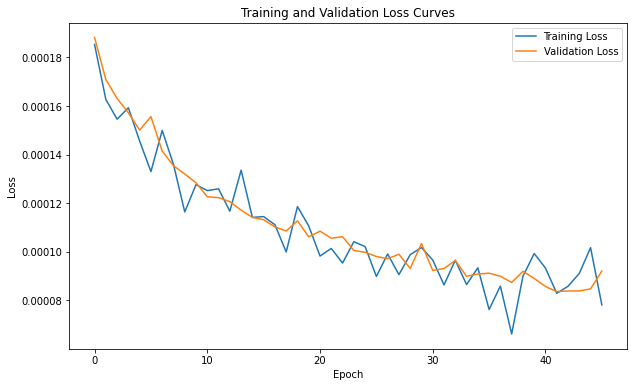

In [283]:
def plot_loss_curves(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()
    
plot_start = 10
plot_loss_curves(train_losses[plot_start:], val_losses[plot_start:])

In [286]:
test_data = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
predictions = model.predict(test_data)

In [287]:
criterion(predictions, test_data)

tensor(8.6543e-05)

In [268]:
predictions.shape

torch.Size([1, 1, 60, 60])

In [269]:
img = Image.fromarray(np.uint8(predictions[0,0,:,:]*255), 'L')
img.show()

In [270]:
img = Image.fromarray(np.uint8(dataset[87,:,:]*255), 'L')
img.show()

In [290]:
model.state_dict()

OrderedDict([('encoder.0.weight',
              tensor([[[[ 0.0393,  0.2002,  0.0803],
                        [ 0.3618,  0.0810, -0.1689],
                        [ 0.1760, -0.0236,  0.1703]]],
              
              
                      [[[ 0.4072, -0.0299,  0.0895],
                        [ 0.2158,  0.0489,  0.3375],
                        [ 0.2526, -0.1529, -0.1006]]],
              
              
                      [[[ 0.2077, -0.2155,  0.0825],
                        [ 0.2768, -0.0037,  0.0498],
                        [ 0.2411, -0.1468,  0.2543]]],
              
              
                      [[[-0.0133, -0.0947, -0.2001],
                        [-0.0770,  0.2287, -0.0768],
                        [-0.2628, -0.1103, -0.2190]]],
              
              
                      [[[-0.1378, -0.0159,  0.1852],
                        [ 0.3305, -0.0562,  0.2475],
                        [ 0.0462, -0.1759,  0.0753]]],
              
              
           